In [10]:
# =========================================================
# Imports
# =========================================================
import json
import math
import copy
import collections
from dataclasses import dataclass
from typing import List, Tuple, Dict, Set
from itertools import combinations


# =========================================================
# Step
# =========================================================
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

@dataclass
class Step:
    tech: str
    desc: str
    impact: int = 1
    removed: List[Tuple[int, int]] = field(default_factory=list)  # 这步删掉的候选格
    placed: Optional[Tuple[int, int]] = None                      # 这步新放的 queen（如果有）
       # 本步放下的 queen（如有）


# =========================================================
# State
# =========================================================
class State:
    def __init__(self, H, W, regions):
        self.H = H
        self.W = W
        self.regions = regions              # regions[r][c]

        self.candidates = {
            (r, c)
            for r in range(H)
            for c in range(W)
        }

        self.queens = set()                 # {(r,c)}
        self.placed_rows = set()
        self.placed_cols = set()
        self.placed_colors = set()


# =========================================================
# King helpers
# =========================================================
def king_neighbors(r, c, H, W):
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            rr, cc = r + dr, c + dc
            if 0 <= rr < H and 0 <= cc < W:
                yield rr, cc


# =========================================================
# Core operations
# =========================================================
def place_queen(state: State, r, c):
    if r in state.placed_rows:
        raise ValueError("Row conflict")
    if c in state.placed_cols:
        raise ValueError("Col conflict")
    if state.regions[r][c] in state.placed_colors:
        raise ValueError("Color conflict")

    state.queens.add((r, c))
    state.placed_rows.add(r)
    state.placed_cols.add(c)
    state.placed_colors.add(state.regions[r][c])

    # remove all conflicting candidates
    remove = set()
    for rr, cc in state.candidates:
        if rr == r or cc == c:
            remove.add((rr, cc))
        elif (rr, cc) in king_neighbors(r, c, state.H, state.W):
            remove.add((rr, cc))
        elif state.regions[rr][cc] == state.regions[r][c]:
            remove.add((rr, cc))

    state.candidates -= remove
    return remove  # <<<<<< 返回删掉的候选格


# =========================================================
# Propagation (basic hard-constraint pruning)
# =========================================================
def propagate(state: State, steps=None):
    removed_total = set()

    changed = True
    while changed:
        changed = False

        to_remove = set()
        for (r, c) in state.candidates:
            # row / col / color already used
            if (r in state.placed_rows) or (c in state.placed_cols) or (state.regions[r][c] in state.placed_colors):
                to_remove.add((r, c))
                continue

            # 3x3 (king neighborhood) constraint
            if any((rr, cc) in state.queens for rr, cc in king_neighbors(r, c, state.H, state.W)):
                to_remove.add((r, c))
                continue

        if to_remove:
            state.candidates -= to_remove
            removed_total |= to_remove
            changed = True

    if steps is not None and removed_total:
        steps.append(
            Step(
                tech="Propagation",
                desc=f"Prune by hard constraints",
                impact=len(removed_total),
                removed=sorted(removed_total)
            )
        )

    return bool(removed_total)

# =========================================================
# Forced move
# =========================================================
def forced_move_once(state: State, steps):
    # Row
    for r in range(state.H):
        if r in state.placed_rows:
            continue
        cells = [(rr, cc) for rr, cc in state.candidates if rr == r]
        if len(cells) == 1:
            (qr, qc) = cells[0]
            removed = place_queen(state, qr, qc)
            steps.append(Step("ForcedMove", f"Row {r} -> place ({qr},{qc})", impact=1, placed=(qr, qc), removed=sorted(removed)))
            return True

    # Column
    for c in range(state.W):
        if c in state.placed_cols:
            continue
        cells = [(rr, cc) for rr, cc in state.candidates if cc == c]
        if len(cells) == 1:
            (qr, qc) = cells[0]
            removed = place_queen(state, qr, qc)
            steps.append(Step("ForcedMove", f"Col {c} -> place ({qr},{qc})", impact=1, placed=(qr, qc), removed=sorted(removed)))
            return True

    # Color
    colors = set(state.regions[r][c] for r, c in state.candidates)
    for col in colors:
        if col in state.placed_colors:
            continue
        cells = [(r, c) for r, c in state.candidates if state.regions[r][c] == col]
        if len(cells) == 1:
            (qr, qc) = cells[0]
            removed = place_queen(state, qr, qc)
            steps.append(Step("ForcedMove", f"Color {col} -> place ({qr},{qc})", impact=1, placed=(qr, qc), removed=sorted(removed)))
            return True

    return False



# =========================================================
# Color → Row / Col Set Lock
# =========================================================
def apply_color_to_row_set_lock(state: State, steps, k_max=2):
    color_rows = collections.defaultdict(set)
    for r, c in state.candidates:
        color_rows[state.regions[r][c]].add(r)

    for k in range(1, k_max + 1):
        for colors in combinations(color_rows.keys(), k):
            rows = set().union(*(color_rows[c] for c in colors))
            if len(rows) != k:
                continue

            removed = set()
            for (r, c) in state.candidates:
                if r in rows and state.regions[r][c] not in colors:
                    removed.add((r, c))

            if removed:
                state.candidates -= removed
                steps.append(
                    Step(
                        f"ColorToRowSetLock{k}",
                        f"Colors {colors} lock rows {sorted(rows)}",
                        impact=len(removed),
                        removed=sorted(removed)
                    )
                )
                return True
    return False


def apply_color_to_col_set_lock(state: State, steps, k_max=2):
    color_cols = collections.defaultdict(set)
    for r, c in state.candidates:
        color_cols[state.regions[r][c]].add(c)

    for k in range(1, k_max + 1):
        for colors in combinations(color_cols.keys(), k):
            cols = set().union(*(color_cols[c] for c in colors))
            if len(cols) != k:
                continue

            removed = set()
            for (r, c) in state.candidates:
                if c in cols and state.regions[r][c] not in colors:
                    removed.add((r, c))

            if removed:
                state.candidates -= removed
                steps.append(
                    Step(
                        f"ColorToColSetLock{k}",
                        f"Colors {colors} lock cols {sorted(cols)}",
                        impact=len(removed),
                        removed=sorted(removed)
                    )
                )
                return True
    return False



# =========================================================
# LocalColorBlockContradiction
# =========================================================
def local_color_block_contradiction(state: State, steps):
    for (r, c) in list(state.candidates):
        blocked = set()
        blocked.add((r, c))
        blocked |= set((r, cc) for cc in range(state.W))
        blocked |= set((rr, c) for rr in range(state.H))
        blocked |= set(king_neighbors(r, c, state.H, state.W))

        for color in set(state.regions[rr][cc] for rr, cc in state.candidates):
            if color == state.regions[r][c]:
                continue

            ok = any(
                (state.regions[rr][cc] == color) and ((rr, cc) not in blocked)
                for (rr, cc) in state.candidates
            )

            if not ok:
                state.candidates.remove((r, c))
                steps.append(
                    Step(
                        "LocalColorBlockContradiction",
                        f"Remove ({r},{c}) blocks color {color}",
                        impact=1,
                        removed=[(r, c)]
                    )
                )
                return True
    return False


def eliminate_by_contradiction(state: State, steps):
    for (r, c) in list(state.candidates):
        test = copy.deepcopy(state)
        try:
            place_queen(test, r, c)
            propagate(test, steps=None)
            while forced_move_once(test, []):
                propagate(test, steps=None)
        except:
            state.candidates.remove((r, c))
            steps.append(
                Step(
                    "EliminateByContradiction",
                    f"Remove ({r},{c}) leads to dead end",
                    impact=1,
                    removed=[(r, c)]
                )
            )
            return True
    return False

# =========================================================
# Solver
# =========================================================
LOGIC_PIPELINE = [
    forced_move_once,
    lambda s, st: apply_color_to_row_set_lock(s, st, 2),
    lambda s, st: apply_color_to_col_set_lock(s, st, 2),
    local_color_block_contradiction,
    eliminate_by_contradiction,
]


# =========================================================
# Solved check
# =========================================================
def is_solved(state: State):
    all_colors = {state.regions[r][c] for r in range(state.H) for c in range(state.W)}
    n_colors = len(all_colors)

    # 颜色：恰好 1 个 queen
    if len(state.queens) != n_colors:
        return False

    color_count = collections.Counter(state.regions[r][c] for (r, c) in state.queens)
    if set(color_count.keys()) != all_colors:
        return False
    if any(v != 1 for v in color_count.values()):
        return False

    # 行列：最多 1（由 len==colors 推不出“没重复”，所以要显式验）
    rows = [r for r, _ in state.queens]
    cols = [c for _, c in state.queens]
    if len(rows) != len(set(rows)):
        return False
    if len(cols) != len(set(cols)):
        return False

    # 任意 3×3 区域内最多 1 (等价 king 邻域无相邻)
    for (r, c) in state.queens:
        for (rr, cc) in king_neighbors(r, c, state.H, state.W):
            if (rr, cc) in state.queens:
                return False

    return True


def solve(state: State):
    steps = []
    propagate(state, steps)  # <<<<<< 记录初始传播
    while True:
        for rule in LOGIC_PIPELINE:
            if rule(state, steps):
                propagate(state, steps)  # <<<<<< 每次规则后记录传播删格
                break
        else:
            break
    return is_solved(state), steps




# =========================================================
# Build from JSON (column-major)
# =========================================================
def build_state_from_level(level):
    H, W = level["SizeY"], level["SizeX"]

    regions = [[0] * W for _ in range(H)]
    for i, v in enumerate(level["GridColours"]):
        r = i % H
        c = i // H
        regions[r][c] = v

    state = State(H, W, regions)

    # place given queens (value == 2)
    for i, v in enumerate(level.get("QueensGrid", [])):
        if v == 2:
            r = i % H
            c = i // H
            place_queen(state, r, c)

    return state




In [22]:
from typing import List
import math
import collections

TECH_WEIGHTS = {
    "Propagation": 0.4,
    "ColorSetLock1": 0.8,
    "ColorSetLock2": 1.2,
    "ColorSetLock3": 1.6,
    "ColorSetLock4": 2.2,
    "ColorSetLock5": 3.0,
    "ColorToRowSetLock1": 0.8,
    "ColorToRowSetLock2": 1.4,
    "ColorToRowSetLock3": 1.8,
    "ColorToRowSetLock4": 2,
    "ColorToRowSetLock5": 2.5,
    "ColorToColSetLock1": 0.8,
    "ColorToColSetLock2": 1.4,
    "ColorToColSetLock3": 1.8,
    "ColorToColSetLock4": 2,
    "ColorToColSetLock5": 2.5,
    
    "KingBoxExclusion": 1,
    "LocalColorBlockContradiction": 5,
    "EliminateByContradiction": 12,
    "ForcedMove": 0.8,
    "Guess": 15,
}

def score_from_steps(steps: List[Step], TECH_WEIGHTS: TECH_WEIGHTS):
    """
    适配当前 solver 的难度评分：
    - tech 权重来自 TECH_WEIGHTS
    - 首次出现加成 FIRST_BONUS
    - 重复出现衰减 REPEAT_DECAY，最低 MIN_REPEAT_FACTOR
    - impact 线性放大（但对 impact 做 CAP，避免传播一次删太多格导致爆炸）
    - 最终映射到 0–100：100*(1-exp(-total/SCORE_SCALE))
    """

    # ====== 可调参数 ======
    FIRST_BONUS = 1.4
    REPEAT_DECAY = 0.65
    MIN_REPEAT_FACTOR = 0.1

    IMPACT_GAIN = 0.10     # 你原来 0.15，这里稍微保守点（Propagation 会比较多）
    IMPACT_CAP = 12        # impact > 12 就按 12 计算，防止一次传播删格太多

    SCORE_SCALE = 30.0

    total = 0.0
    breakdown = collections.defaultdict(lambda: {"count": 0, "impact": 0, "score": 0.0})
    tech_seen = collections.defaultdict(int)

    for st in steps:
        base_w = TECH_WEIGHTS.get(st.tech, 1.0)

        tech_seen[st.tech] += 1
        k = tech_seen[st.tech]

        if k == 1:
            freq_factor = FIRST_BONUS
        else:
            freq_factor = max(MIN_REPEAT_FACTOR, FIRST_BONUS * (REPEAT_DECAY ** (k - 1)))

        eff_impact = min(IMPACT_CAP, max(1, int(st.impact)))
        impact_factor = 1.0 + IMPACT_GAIN * (eff_impact - 1)

        s = base_w * freq_factor * impact_factor
        total += s

        b = breakdown[st.tech]
        b["count"] += 1
        b["impact"] += st.impact
        b["score"] += s

    score = 100.0 * (1.0 - math.exp(-total / SCORE_SCALE))
    return score, dict(breakdown)


In [21]:
# json_path = "/Users/fanzichen/Downloads/LevelDump.json"
# run_levels(json_path, limit=100)

In [19]:
# =========================================================
# Pretty print helpers
# =========================================================
def print_grid(grid, title=None):
    if title:
        print(title)
    for row in grid:
        print(" ".join(f"{x:2}" for x in row))
    print()


def print_queen_grid(H, W, queens, title):
    print(title)
    board = [["." for _ in range(W)] for _ in range(H)]
    for r, c in queens:
        board[r][c] = "Q"
    for row in board:
        print(" ".join(row))
    print()


# =========================================================
# Show puzzle (with given queens)
# =========================================================
def show_puzzle(level):
    H, W = level["SizeY"], level["SizeX"]

    # column-major → row-major
    regions = [[0] * W for _ in range(H)]
    for i, v in enumerate(level["GridColours"]):
        r = i % H
        c = i // H
        regions[r][c] = v

    given = set()
    for i, v in enumerate(level.get("QueensGrid", [])):
        if v == 2:
            r = i % H
            c = i // H
            given.add((r, c))

    print("=" * 60)
    print(f"Puzzle Size: {H} x {W}")
    print(f"Given Queens: {len(given)}\n")

    print_grid(regions, "Color Regions:")
    print_queen_grid(H, W, given, "Given Queens (QueensGrid == 2):")

    return regions, given


# =========================================================
# Show solve steps
# =========================================================
def show_steps(steps):
    print("=" * 60)
    print("Solve Steps:")
    if not steps:
        print("  (no logical progress)")
        return

    for i, st in enumerate(steps, 1):
        print(f"{i:02d}. [{st.tech}] impact={st.impact}")
        print(f"    {st.desc}")

        if st.placed is not None:
            pr, pc = st.placed
            print(f"    placed: ({pr},{pc})")

        if st.removed:
            # 你也可以改成按行排序更好看；这里直接输出坐标列表
            print(f"    removed({len(st.removed)}): {st.removed}")

    print(f"\nTotal steps: {len(steps)}")




# =========================================================
# Show final solution
# =========================================================
def show_solution(state: State):
    print("=" * 60)
    print("Final Solution:")
    board = [["." for _ in range(state.W)] for _ in range(state.H)]
    for r, c in state.queens:
        board[r][c] = "Q"
    for row in board:
        print(" ".join(row))
    print()





# =========================================================
# Run single level with full detail
# =========================================================
def run_single_level(json_path, level_index: int):
    with open(json_path, "r", encoding="utf-8") as f:
        levels = json.load(f)["LevelOrder"]

    if not (1 <= level_index <= len(levels)):
        raise ValueError("Level index out of range")

    level = levels[level_index - 1]

    # 1. Show puzzle
    show_puzzle(level)

    # 2. Solve
    state = build_state_from_level(level)
    solved, steps = solve(state)

    # 3. Difficulty
    score, breakdown = score_from_steps(steps)
    max_tech = max(
        (s.tech for s in steps),
        default=None,
        key=lambda t: TECH_WEIGHTS.get(t, 0)
    )

    print("=" * 60)
    print(f"Solved: {solved}")
    print(f"Difficulty Score: {score:.2f}")
    print(f"Highest Technique: {max_tech}")

    # 4. Steps
    show_steps(steps)

    # 5. Final board
    show_solution(state)
#     show_board_with_given(state, given_queens)


In [23]:
# json_path = "/Users/fanzichen/Downloads/LevelDump.json"
run_single_level(json_path, level_index=18)


Puzzle Size: 9 x 9
Given Queens: 1

Color Regions:
 0  0  1  1  1  1  1  1  1
 1  0  1  1  1  5  1  1  1
 1  1  1  1  3  5  1  8  8
 2  2  1  3  3  5  5  5  8
 2  2  2  2  3  3  3  3  3
 2  2  2  2  3  3  3  3  3
 2  2  2  4  4  6  7  3  3
 2  2  2  4  4  6  7  7  7
 2  2  2  2  4  6  6  6  7

Given Queens (QueensGrid == 2):
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . Q . . .



TypeError: score_from_steps() missing 1 required positional argument: 'TECH_WEIGHTS'

In [116]:
import numpy as np
import matplotlib.pyplot as plt


def parse_level(level):
    H, W = level["SizeY"], level["SizeX"]

    regions = np.zeros((H, W), dtype=int)
    queens = np.zeros((H, W), dtype=int)

    # column-major -> row-major
    for i, v in enumerate(level["GridColours"]):
        r = i % H
        c = i // H
        regions[r, c] = v

    for i, v in enumerate(level.get("QueensGrid", [])):
        if v == 2:
            r = i % H
            c = i // H
            queens[r, c] = 1

    return regions, queens


def plot_initial_board(level, title="Initial Board"):
    regions, queens = parse_level(level)
    H, W = regions.shape

    fig, ax = plt.subplots(figsize=(W, H))

    # ===== 使用柔和色盘 =====
    unique_regions = np.unique(regions)
    base_cmap = plt.colormaps["Pastel1"]   # 👈 柔和
    cmap = base_cmap.resampled(len(unique_regions))

    ax.imshow(regions, cmap=cmap)

    # ===== 网格线 =====
    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=1)

    ax.set_xticks(np.arange(W))
    ax.set_yticks(np.arange(H))
    ax.set_xticklabels(range(W))
    ax.set_yticklabels(range(H))

    # ===== Queen（QueensGrid == 2）=====
    for r in range(H):
        for c in range(W):
            if queens[r, c]:
                ax.text(
                    c, r, "♛",
                    ha="center",
                    va="center",
                    fontsize=28,
                    color="black"
                )

    # ===== 关键：只在显示层翻转一次 =====
#     ax.invert_yaxis()

    ax.set_title(title)
    plt.tight_layout()
    plt.show()
with open("/Users/fanzichen/Downloads/LevelDump.json", "r", encoding="utf-8") as f:
    levels = json.load(f)["LevelOrder"]

level = levels[24-1]  # 第 1 关
plot_initial_board(level)

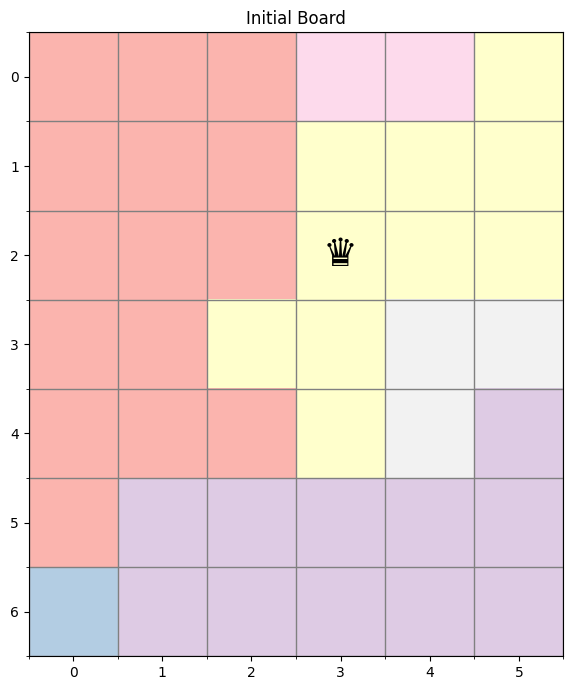

In [26]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

from __future__ import annotations

import re
import shutil
from pathlib import Path
from typing import Optional, Tuple

import pandas as pd


# =========================
# 配置区（按需修改）
# =========================
BASE_DIR = Path("/Users/fanzichen/广告变现/generated_libraries")

# 输出汇总目录（会自动创建）
OUT_DIR = BASE_DIR.parent / "queen_master_merged_library"

# 合并后的大 CSV 文件名
OUT_CSV_NAME = "summary_merged.csv"

# 新 level_id 格式：L000001 / L000002 ...（你也可以改成纯数字）
NEW_ID_PREFIX = "L"
NEW_ID_WIDTH = 6

# 是否在 merged csv 里保留原始库信息
KEEP_SOURCE_COLUMNS = True


# =========================
# 工具函数
# =========================
LEVEL_NUM_RE = re.compile(r"level[_-]?(\d+)", re.IGNORECASE)

def infer_level_index(row: pd.Series) -> Optional[int]:
    """
    尝试从 row['level_id'] 推断原始关卡编号(例如 level_001 -> 1)。
    若失败返回 None。
    """
    if "level_id" not in row or pd.isna(row["level_id"]):
        return None
    s = str(row["level_id"])
    m = LEVEL_NUM_RE.search(s)
    if not m:
        return None
    try:
        return int(m.group(1))
    except ValueError:
        return None


def build_src_paths(folder: Path, level_idx: int) -> Tuple[Path, Path]:
    """
    根据子库 folder 和 level_idx 生成原始 png/json 路径。
    默认使用 level_{idx:03d}.png/json
    """
    png = folder / "plots" / f"level_{level_idx:03d}.png"
    jsn = folder / "levels" / f"level_{level_idx:03d}.json"
    return png, jsn


def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def new_level_id(i: int) -> str:
    return f"{NEW_ID_PREFIX}{i:0{NEW_ID_WIDTH}d}"


# =========================
# 主流程
# =========================
def main() -> None:
    if not BASE_DIR.exists():
        raise FileNotFoundError(f"BASE_DIR 不存在: {BASE_DIR}")

    out_levels_dir = OUT_DIR / "levels"
    out_plots_dir = OUT_DIR / "plots"
    ensure_dir(out_levels_dir)
    ensure_dir(out_plots_dir)

    # 找到所有 summary.csv
    summary_files = sorted(BASE_DIR.rglob("summary.csv"))
    if not summary_files:
        raise FileNotFoundError(f"在 {BASE_DIR} 下没有找到任何 summary.csv")

    all_rows = []
    next_id = 1
    copied_png = 0
    copied_json = 0
    skipped = 0

    for summary_path in summary_files:
        folder = summary_path.parent  # 子库目录，如 .../5x4_c4_g0_d0-25
        try:
            df = pd.read_csv(summary_path)
        except Exception as e:
            print(f"[WARN] 读取失败，跳过: {summary_path} ({e})")
            continue

        if df.empty:
            continue

        # 可选：记录来源库信息，方便追溯
        if KEEP_SOURCE_COLUMNS:
            df["source_folder"] = str(folder)
            df["source_summary"] = str(summary_path)

        for _, row in df.iterrows():
            idx = infer_level_index(row)
            if idx is None:
                # 如果你的 summary.csv 里 level_id 不是 level_001 这种形式，
                # 可以在这里改策略，比如从行号推断。
                skipped += 1
                continue

            src_png, src_json = build_src_paths(folder, idx)
            if not src_png.exists() or not src_json.exists():
                print(f"[WARN] 缺文件，跳过: {folder.name} idx={idx} "
                      f"png={src_png.exists()} json={src_json.exists()}")
                skipped += 1
                continue

            nid = new_level_id(next_id)
            next_id += 1

            # 复制并重命名到汇总目录
            dst_png = out_plots_dir / f"{nid}.png"
            dst_json = out_levels_dir / f"{nid}.json"

            shutil.copy2(src_png, dst_png)
            shutil.copy2(src_json, dst_json)
            copied_png += 1
            copied_json += 1

            # 组装输出行：保留原字段 + 新字段
            out_row = row.to_dict()
            out_row["level_id_old"] = out_row.get("level_id", None)
            out_row["level_id"] = nid  # 用新 id 覆盖（更方便直接使用）
            out_row["plot_path"] = str(dst_png)
            out_row["json_path"] = str(dst_json)

            # 也可以保留原始文件路径（可选）
            out_row["plot_path_old"] = str(src_png)
            out_row["json_path_old"] = str(src_json)

            all_rows.append(out_row)

    merged_df = pd.DataFrame(all_rows)

    # 输出合并 CSV
    out_csv = OUT_DIR / OUT_CSV_NAME
    ensure_dir(OUT_DIR)
    merged_df.to_csv(out_csv, index=False)

    print("========== DONE ==========")
    print(f"Found summary.csv: {len(summary_files)}")
    print(f"Merged levels:     {len(merged_df)}")
    print(f"Copied png:        {copied_png}")
    print(f"Copied json:       {copied_json}")
    print(f"Skipped rows:      {skipped}")
    print(f"Output dir:        {OUT_DIR}")
    print(f"Output csv:        {out_csv}")


# if __name__ == "__main__":
#     main()


In [27]:
main()

========== DONE ==========
Found summary.csv: 37
Merged levels:     0
Copied png:        0
Copied json:       0
Skipped rows:      209
Output dir:        /Users/fanzichen/广告变现/queen_master_merged_library
Output csv:        /Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv


In [28]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
import shutil
from pathlib import Path
import pandas as pd


def normalize_level_stem(level_id) -> str:
    """
    把各种可能的 level_id 归一化为: level_001 这样的 stem（不带扩展名）
    允许输入例子：
      1, "1", "001", "level_1", "level_001", "Level-001", "level 001"
    """
    if pd.isna(level_id):
        return ""

    s = str(level_id).strip()

    # 直接抓取末尾的数字（或字符串中的数字）
    # 优先找连续数字段
    m = re.search(r"(\d+)", s)
    if not m:
        return ""

    n = int(m.group(1))
    return f"level_{n:03d}"


def safe_read_csv(csv_path: Path) -> pd.DataFrame:
    """
    尽量兼容编码（utf-8 / utf-8-sig / gbk 等）
    """
    for enc in ("utf-8-sig", "utf-8", "gbk"):
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    # 最后兜底：让 pandas 自己猜，但可能会有乱码
    return pd.read_csv(csv_path, encoding_errors="replace")


def merge_queen_master_libraries(
    root_dir: str,
    out_dir: str,
    new_id_prefix: str = "L",
    id_width: int = 6,
    dry_run: bool = False,
    verbose_missing: bool = True,
) -> None:
    root = Path(root_dir).expanduser().resolve()
    out = Path(out_dir).expanduser().resolve()

    out_plots = out / "plots"
    out_levels = out / "levels"
    out.mkdir(parents=True, exist_ok=True)
    out_plots.mkdir(parents=True, exist_ok=True)
    out_levels.mkdir(parents=True, exist_ok=True)

    summary_paths = sorted(root.rglob("summary.csv"))

    merged_rows = []
    copied_png = 0
    copied_json = 0
    skipped = 0

    next_id = 1

    # 记录（源文件 -> 新文件）防止重复复制同一关（可选）
    # key: (folder, normalized_stem)
    seen = set()

    for summary_csv in summary_paths:
        folder = summary_csv.parent

        # 必须同时有 plots/ levels/ 才认为是关卡库目录
        plots_dir = folder / "plots"
        levels_dir = folder / "levels"
        if not plots_dir.is_dir() or not levels_dir.is_dir():
            continue

        df = safe_read_csv(summary_csv)

        if "level_id" not in df.columns:
            if verbose_missing:
                print(f"[WARN] no level_id column: {summary_csv}")
            continue

        for _, row in df.iterrows():
            norm_stem = normalize_level_stem(row.get("level_id"))
            if not norm_stem:
                skipped += 1
                if verbose_missing:
                    print(f"[SKIP] bad level_id: {row.get('level_id')} in {summary_csv}")
                continue

            key = (str(folder), norm_stem)
            if key in seen:
                # 如果同一个 summary.csv 里重复，跳过
                skipped += 1
                continue
            seen.add(key)

            src_png = plots_dir / f"{norm_stem}.png"
            src_json = levels_dir / f"{norm_stem}.json"

            if not src_png.exists() or not src_json.exists():
                skipped += 1
                if verbose_missing:
                    miss = []
                    if not src_png.exists():
                        miss.append("png")
                    if not src_json.exists():
                        miss.append("json")
                    print(f"[SKIP] missing {','.join(miss)} for {folder.name}/{norm_stem}")
                continue

            new_level_id = f"{new_id_prefix}{next_id:0{id_width}d}"
            next_id += 1

            dst_png = out_plots / f"{new_level_id}.png"
            dst_json = out_levels / f"{new_level_id}.json"

            if not dry_run:
                shutil.copy2(src_png, dst_png)
                shutil.copy2(src_json, dst_json)
            copied_png += 1
            copied_json += 1

            # 输出 CSV 中记录“新路径”（建议用相对路径，方便移动目录）
            out_row = row.to_dict()

            out_row["level_id_old"] = row.get("level_id")
            out_row["level_id"] = new_level_id
            out_row["source_folder"] = str(folder)
            out_row["source_summary_csv"] = str(summary_csv)

            out_row["plot_path"] = str(dst_png)
            out_row["json_path"] = str(dst_json)

            out_row["plot_path_rel"] = str(dst_png.relative_to(out))
            out_row["json_path_rel"] = str(dst_json.relative_to(out))

            merged_rows.append(out_row)

    merged_df = pd.DataFrame(merged_rows)

    out_csv = out / "summary_merged.csv"
    if not dry_run:
        merged_df.to_csv(out_csv, index=False, encoding="utf-8-sig")

    print("========== DONE ==========")
    print(f"Found summary.csv: {len(summary_paths)}")
    print(f"Merged levels:     {len(merged_df)}")
    print(f"Copied png:        {copied_png}")
    print(f"Copied json:       {copied_json}")
    print(f"Skipped rows:      {skipped}")
    print(f"Output dir:        {out}")
    print(f"Output csv:        {out_csv}")


if __name__ == "__main__":
    merge_queen_master_libraries(
        root_dir="/Users/fanzichen/广告变现/generated_libraries",
        out_dir="/Users/fanzichen/广告变现/queen_master_merged_library",
        new_id_prefix="L",
        id_width=6,
        dry_run=False,          # 先想测试可以改 True
        verbose_missing=True,   # 会打印跳过原因
    )


========== DONE ==========
Found summary.csv: 37
Merged levels:     209
Copied png:        209
Copied json:       209
Skipped rows:      0
Output dir:        /Users/fanzichen/广告变现/queen_master_merged_library
Output csv:        /Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv


In [29]:
def sanity_check(out_dir):
    out = Path(out_dir)
    csv_path = out / "summary_merged.csv"
    df = pd.read_csv(csv_path)

    missing_png = []
    missing_json = []

    for _, r in df.iterrows():
        if not Path(r["plot_path"]).exists():
            missing_png.append(r["level_id"])
        if not Path(r["json_path"]).exists():
            missing_json.append(r["level_id"])

    print("Sanity check:")
    print("  missing png :", len(missing_png))
    print("  missing json:", len(missing_json))


# 合并关卡库

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import json
import shutil
import argparse
from pathlib import Path
from collections import defaultdict

import pandas as pd

# -----------------------------
# 可按你项目实际 JSON 结构定制的字段提取
# -----------------------------
def extract_dims_from_level_json(j: dict):
    """
    尝试从 level json 中提取 rows/cols/color_count。
    由于你没贴 json 格式，这里做“尽量兼容”的多路径探测。
    找不到就返回 None。
    """
    # 常见命名尝试
    candidates = [
        ("rows", "cols", "color_count"),
        ("row", "col", "colorCount"),
        ("height", "width", "color_count"),
        ("height", "width", "colorCount"),
    ]
    for r_key, c_key, cc_key in candidates:
        if r_key in j and c_key in j:
            rows = j.get(r_key)
            cols = j.get(c_key)
            color_count = j.get(cc_key, None)
            return rows, cols, color_count

    # 嵌套结构尝试
    # e.g. {"board": {"rows":..,"cols":..}, "color_count":..}
    if "board" in j and isinstance(j["board"], dict):
        b = j["board"]
        rows = b.get("rows", b.get("height", None))
        cols = b.get("cols", b.get("width", None))
        color_count = j.get("color_count", j.get("colorCount", b.get("color_count", b.get("colorCount", None))))
        if rows is not None and cols is not None:
            return rows, cols, color_count

    # 从网格推断 rows/cols
    # e.g. {"grid": [[...],[...]]}
    for gk in ("grid", "cells", "board"):
        if gk in j and isinstance(j[gk], list) and j[gk] and isinstance(j[gk][0], list):
            rows = len(j[gk])
            cols = len(j[gk][0]) if j[gk][0] else None
            # color_count 很难从 grid 准确推断（除非网格里就是颜色 id）
            return rows, cols, None

    return None, None, None


# -----------------------------
# difficulty 编码策略
# -----------------------------
def difficulty_bucket_from_generated_score(generated_score, step=5):
    """
    使用 generated_score，映射到最近的 step(默认5) 的倍数
    例如：
      12.1 -> 10
      12.6 -> 15
    返回形如：d10, d15
    """
    try:
        gs = float(generated_score)
    except (TypeError, ValueError):
        return "dNA"

    bucket = int(round(gs / step) * step)
    return f"d{bucket:02d}"


def make_level_id(rows, cols, color_count, diff_code, seq):
    """
    level_id 编码规则（你可以随便改格式）：
      Q_{rows}x{cols}_c{color_count}_{diff_code}_{seq:05d}
    例：Q_5x4_c4_d07_00012
    """
    r = int(rows)
    c = int(cols)
    cc = int(color_count) if color_count is not None and pd.notna(color_count) else -1
    cc_part = f"c{cc}" if cc >= 0 else "cNA"
    return f"Q_{r}x{c}_{cc_part}_{diff_code}_{seq:05d}"


# -----------------------------
# 一致性校验
# -----------------------------
def validate_row(row, png_path: Path, json_path: Path, strict_json_check=True):
    """
    返回 (ok: bool, issues: list[str], extracted: dict)
    """
    issues = []
    extracted = {}

    if not png_path.exists():
        issues.append(f"PNG缺失: {png_path}")
    if not json_path.exists():
        issues.append(f"JSON缺失: {json_path}")

    # JSON 解析 + 维度校验
    if strict_json_check and json_path.exists():
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                j = json.load(f)
            jr, jc, jcc = extract_dims_from_level_json(j)
            extracted["json_rows"] = jr
            extracted["json_cols"] = jc
            extracted["json_color_count"] = jcc

            # summary 中的 rows/cols 必须能比对
            sr = row.get("rows", None)
            sc = row.get("cols", None)
            scc = row.get("color_count", None)

            if pd.notna(sr) and jr is not None and int(sr) != int(jr):
                issues.append(f"rows不一致 summary={sr} json={jr}")
            if pd.notna(sc) and jc is not None and int(sc) != int(jc):
                issues.append(f"cols不一致 summary={sc} json={jc}")

            # color_count：json 可能没有，若有则比对
            if pd.notna(scc) and jcc is not None:
                try:
                    if int(scc) != int(jcc):
                        issues.append(f"color_count不一致 summary={scc} json={jcc}")
                except Exception:
                    issues.append(f"color_count无法比对 summary={scc} json={jcc}")

        except Exception as e:
            issues.append(f"JSON解析失败: {json_path} err={e}")

    ok = len(issues) == 0
    return ok, issues, extracted


# -----------------------------
# 主流程
# -----------------------------
def find_summary_csvs(src_root: Path):
    return sorted(src_root.rglob("summary.csv"))


def merge_all(
    src_root: Path,
    out_root: Path,
    difficulty_strategy="avg_int",
    strict_json_check=True,
    skip_unsolved=False,
    only_unique=False,
    dry_run=False,
):
    out_root.mkdir(parents=True, exist_ok=True)
    out_plots = out_root / "plots"
    out_levels = out_root / "levels"
    out_plots.mkdir(parents=True, exist_ok=True)
    out_levels.mkdir(parents=True, exist_ok=True)

    summary_paths = find_summary_csvs(src_root)

    print(f"Found summary.csv: {len(summary_paths)}")

    merged_rows = []
    skipped_rows = 0
    copied_png = 0
    copied_json = 0

    # 为每个 (rows,cols,color_count,diff_bucket) 分组计数生成递增 seq
    seq_counter = defaultdict(int)

    # 用于防止重复：同源文件重复导入
    seen_source = set()

    # 记录校验问题
    issues_log = []

    for sp in summary_paths:
        folder = sp.parent
        plots_dir = folder / "plots"
        levels_dir = folder / "levels"

        try:
            df = pd.read_csv(sp)
        except Exception as e:
            issues_log.append({"type": "csv_read_fail", "summary_csv": str(sp), "error": str(e)})
            continue

        # 可选过滤
        if skip_unsolved and "solved" in df.columns:
            df = df[df["solved"] == True]
        if only_unique and "is_unique" in df.columns:
            df = df[df["is_unique"] == True]

        for _, row in df.iterrows():
            level_id_old = row.get("level_id", None)

            # 从 level_id 推断文件名：默认 level_001 / level_002 这种
            # 如果你的 summary.csv 里 level_id 就是 "level_001"，那直接用
            if isinstance(level_id_old, str) and level_id_old.startswith("level_"):
                stem = level_id_old
            else:
                # 否则尝试把数字转成 level_XXX
                # 例：1 => level_001
                try:
                    n = int(level_id_old)
                    stem = f"level_{n:03d}"
                except Exception:
                    # 再不行就跳过
                    skipped_rows += 1
                    issues_log.append({
                        "type": "bad_level_id",
                        "summary_csv": str(sp),
                        "row_level_id": str(level_id_old),
                        "error": "无法推断关卡文件名（期望 level_001 或可转 int）"
                    })
                    continue

            png_path = plots_dir / f"{stem}.png"
            json_path = levels_dir / f"{stem}.json"

            # 防止重复导入同一源
            source_key = (str(png_path), str(json_path))
            if source_key in seen_source:
                skipped_rows += 1
                issues_log.append({
                    "type": "duplicate_source",
                    "summary_csv": str(sp),
                    "png": str(png_path),
                    "json": str(json_path),
                    "error": "源文件重复导入，已跳过"
                })
                continue
            seen_source.add(source_key)

            # 一致性校验
            ok, issues, extracted = validate_row(
                row=row,
                png_path=png_path,
                json_path=json_path,
                strict_json_check=strict_json_check,
            )
            if not ok:
                skipped_rows += 1
                issues_log.append({
                    "type": "validation_fail",
                    "summary_csv": str(sp),
                    "stem": stem,
                    "png": str(png_path),
                    "json": str(json_path),
                    "issues": " | ".join(issues),
                })
                continue

            # 生成新 level_id
            rows = row.get("rows", None)
            cols = row.get("cols", None)
            color_count = row.get("color_count", None)

            if pd.isna(rows) or pd.isna(cols):
                skipped_rows += 1
                issues_log.append({
                    "type": "missing_dims",
                    "summary_csv": str(sp),
                    "stem": stem,
                    "error": f"summary缺少 rows/cols rows={rows} cols={cols}"
                })
                continue

            diff_code = difficulty_bucket_from_generated_score(row.get("generated_score"))

            key = (int(rows), int(cols), int(color_count) if pd.notna(color_count) else -1, diff_code)
            seq_counter[key] += 1
            new_id = make_level_id(rows, cols, color_count, diff_code, seq_counter[key])

            # 输出路径
            new_png = out_plots / f"{new_id}.png"
            new_json = out_levels / f"{new_id}.json"

            if not dry_run:
                # copy2 保留修改时间等元信息
                shutil.copy2(png_path, new_png)
                shutil.copy2(json_path, new_json)
            copied_png += 1
            copied_json += 1

            # 合并行：增加新字段
            out_row = row.to_dict()
            out_row["level_id_old"] = level_id_old
            out_row["level_id"] = new_id
            out_row["source_folder"] = str(folder)
            out_row["source_summary_csv"] = str(sp)
            out_row["plot_path"] = str(new_png)
            out_row["json_path"] = str(new_json)

            # 可选：把 json 提取到的维度也写入，方便排查
            for k, v in extracted.items():
                out_row[k] = v

            merged_rows.append(out_row)

    # 合并输出
    merged_df = pd.DataFrame(merged_rows)

    # 新 level_id 冲突检查（理论上不会，但还是做一下）
    if not merged_df.empty:
        dup = merged_df["level_id"].duplicated().sum()
        if dup > 0:
            issues_log.append({"type": "new_level_id_collision", "count": int(dup), "error": "新level_id出现重复，请检查编码规则或源数据"})
            # 发生冲突时，也可以选择直接 raise
            # raise RuntimeError("新 level_id 冲突，请检查编码规则。")

    out_csv = out_root / "summary_merged.csv"
    out_issues = out_root / "merge_issues.csv"

    if not dry_run:
        merged_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
        if issues_log:
            pd.DataFrame(issues_log).to_csv(out_issues, index=False, encoding="utf-8-sig")

    print("========== DONE ==========")
    print(f"Found summary.csv: {len(summary_paths)}")
    print(f"Merged levels:     {len(merged_rows)}")
    print(f"Copied png:        {copied_png}")
    print(f"Copied json:       {copied_json}")
    print(f"Skipped rows:      {skipped_rows}")
    print(f"Output dir:        {out_root}")
    print(f"Output csv:        {out_csv}")
    if issues_log:
        print(f"Issues csv:        {out_issues}")

    return merged_df


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--src_root", type=str, default="/Users/fanzichen/广告变现/generated_libraries")
    parser.add_argument("--out_root", type=str, default="/Users/fanzichen/广告变现/queen_master_merged_library")
    parser.add_argument("--difficulty_strategy", type=str, default="avg_int",
                        choices=["avg_int", "range", "avg_1dp", "raw"])
    parser.add_argument("--no_strict_json_check", action="store_true", help="关闭读取json进行一致性校验")
    parser.add_argument("--skip_unsolved", action="store_true", help="若summary包含solved列，只保留solved==True")
    parser.add_argument("--only_unique", action="store_true", help="若summary包含is_unique列，只保留is_unique==True")
    parser.add_argument("--dry_run", action="store_true", help="只跑流程不拷贝不写文件")
    args = parser.parse_args()

    src_root = Path(args.src_root)
    out_root = Path(args.out_root)

    merge_all(
        src_root=src_root,
        out_root=out_root,
        difficulty_strategy=args.difficulty_strategy,
        strict_json_check=not args.no_strict_json_check,
        skip_unsolved=args.skip_unsolved,
        only_unique=args.only_unique,
        dry_run=args.dry_run,
    )


if __name__ == "__main__":
    try:
        # 只有在真正的命令行环境才用 argparse
        get_ipython
        # 如果能拿到 get_ipython，说明在 Jupyter，直接走默认参数
        merge_all(
            src_root=Path("/Users/fanzichen/广告变现/generated_libraries"),
            out_root=Path("/Users/fanzichen/广告变现/queen_master_merged_library"),
            difficulty_strategy="avg_int",
            strict_json_check=True,
            skip_unsolved=False,
            only_unique=False,
            dry_run=False,
        )
    except NameError:
        # 纯命令行运行
        main()


Found summary.csv: 118
========== DONE ==========
Found summary.csv: 118
Merged levels:     4387
Copied png:        4387
Copied json:       4387
Skipped rows:      500
Output dir:        /Users/fanzichen/广告变现/queen_master_merged_library
Output csv:        /Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv
Issues csv:        /Users/fanzichen/广告变现/queen_master_merged_library/merge_issues.csv


In [73]:
import pandas as pd
import json
import math
from pathlib import Path

A_PATH = r"/Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv"
B_PATH = r"/Users/fanzichen/广告变现/queen_master_merged_library1230/summary_merged.csv"
OUT_PATH = r"/Users/fanzichen/广告变现/queen_master_A_not_in_B_0105.csv"

# A_PATH =  r"/Users/fanzichen/广告变现/queen_master_A_not_in_B_1022.csv"
# B_PATH = r"/Users/fanzichen/Downloads/queen_master_A_not_in_B.csv"

# A_PATH =  r"/Users/fanzichen/广告变现/queen_master_A_not_in_B_1022_1.csv"
# B_PATH = r"/Users/fanzichen/Downloads/queen_master_A_not_in_B_v3.csv"

# OUT_PATH = r"/Users/fanzichen/广告变现/queen_master_A_not_in_B_1022_2.csv"

KEY_COLS = [
    "rows", "cols", "color_count", "given_queens",
    "generated_score",
    "highest_tech",
    "tech_set", "tech_steps"]

# import pandas as pd
# import json
# import math
# from pathlib import Path

# A_PATH = r"/Users/fanzichen/广告变现/queen_master_merged_library 2/summary_merged.csv"
# B_PATH = r"/Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv"
# OUT_PATH = r"/Users/fanzichen/广告变现/queen_master_A_not_in_B_all_cols.csv"

# KEY_COLS = [
#     "rows", "cols", "color_count", "given_queens",
#     "difficulty_lo", "difficulty_hi", "generated_score",
#     "highest_tech", "tech_set", "tech_steps",
#     "tech_count", "total_steps", "is_unique"
# ]

# ---------------- normalize helpers ----------------

def _to_int(x):
    if pd.isna(x): return None
    try: return int(float(x))
    except: return None

def _to_float(x, ndigits=6):
    if pd.isna(x): return None
    try:
        v = float(x)
        return round(v, ndigits) if math.isfinite(v) else None
    except:
        return None

def _to_bool(x):
    if pd.isna(x): return None
    if isinstance(x, bool): return x
    s = str(x).strip().lower()
    if s in ("1", "true", "t", "yes"): return True
    if s in ("0", "false", "f", "no"): return False
    return None

def _norm_str(x):
    return "" if pd.isna(x) else str(x).strip()

def _norm_tech_set(x):
    s = _norm_str(x)
    if not s: return ""
    sep = "|" if "|" in s and "," not in s else ","
    parts = [p.strip() for p in s.split(sep) if p.strip()]
    return ",".join(sorted(set(parts)))

def _norm_tech_steps(x):
    s = _norm_str(x)
    if not s:
        return "{}"

    # JSON
    try:
        obj = json.loads(s)
        if isinstance(obj, dict):
            obj2 = {}
            for k, v in obj.items():
                k = str(k).strip()
                try: v = int(v)
                except:
                    try: v = float(v)
                    except: pass
                obj2[k] = v
            return json.dumps(dict(sorted(obj2.items())), ensure_ascii=False, separators=(",", ":"))
    except:
        pass

    # "A:1|B:2"
    if "|" in s and ":" in s:
        d = {}
        for part in s.split("|"):
            if ":" not in part:
                continue
            k, v = part.split(":", 1)
            k = k.strip()
            v = v.strip()
            try: v = int(v)
            except:
                try: v = float(v)
                except: pass
            d[k] = v
        return json.dumps(dict(sorted(d.items())), ensure_ascii=False, separators=(",", ":"))

    return s

# ---------------- normalize only for comparison ----------------

def normalize_keys(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in KEY_COLS:
        if c not in df.columns:
            df[c] = None

    df["rows"] = df["rows"].map(_to_int)
    df["cols"] = df["cols"].map(_to_int)
    df["color_count"] = df["color_count"].map(_to_int)
    df["given_queens"] = df["given_queens"].map(_to_int)

    df["difficulty_lo"] = df["difficulty_lo"].map(_to_float)
    df["difficulty_hi"] = df["difficulty_hi"].map(_to_float)
    df["generated_score"] = df["generated_score"].map(_to_float)

    df["highest_tech"] = df["highest_tech"].map(_norm_str)
    df["tech_set"] = df["tech_set"].map(_norm_tech_set)
    df["tech_steps"] = df["tech_steps"].map(_norm_tech_steps)

    df["tech_count"] = df["tech_count"].map(_to_int)
    df["total_steps"] = df["total_steps"].map(_to_int)
    df["is_unique"] = df["is_unique"].map(_to_bool)

    return df[KEY_COLS]

# ---------------- main diff logic ----------------

def a_not_in_b_keep_all_cols(df_a: pd.DataFrame, df_b: pd.DataFrame) -> pd.DataFrame:
    a_keys = normalize_keys(df_a)
    b_keys = normalize_keys(df_b).drop_duplicates()

    # 用 index 对齐，避免丢列
    a_with_keys = df_a.copy()
    for c in KEY_COLS:
        a_with_keys[f"_key_{c}"] = a_keys[c]

    b_with_keys = b_keys.copy()
    for c in KEY_COLS:
        b_with_keys[f"_key_{c}"] = b_keys[c]

    key_cols_tmp = [f"_key_{c}" for c in KEY_COLS]

    merged = a_with_keys.merge(
        b_with_keys[key_cols_tmp],
        on=key_cols_tmp,
        how="left",
        indicator=True
    )

    result = merged[merged["_merge"] == "left_only"].drop(columns=["_merge"] + key_cols_tmp)
    return result.reset_index(drop=True)

# ---------------- run ----------------

def main():
    df_a = pd.read_csv(A_PATH)
    df_b = pd.read_csv(B_PATH)

    result = a_not_in_b_keep_all_cols(df_a, df_b)

    Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    result.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

    print("A rows:", len(df_a))
    print("B rows:", len(df_b))
    print("A - B rows (all cols kept):", len(result))
    print("Saved to:", OUT_PATH)

if __name__ == "__main__":
    main()


A rows: 4087
B rows: 641
A - B rows (all cols kept): 3431
Saved to: /Users/fanzichen/广告变现/queen_master_A_not_in_B_0105.csv


In [27]:
# df_a.columns

In [19]:
# import pandas as pd

# # -------- paths --------

# # csv_a = "/Users/fanzichen/广告变现/queen_master原版level1000/level_summary1000.csv"
# # csv_b = "/Users/fanzichen/广告变现/generated200/generated_summary.csv"
# # out_csv = "/Users/fanzichen/广告变现/generated200/level_summary_joined.csv"

# # -------- load --------
# df_a = pd.read_csv(csv_a)
# df_b = pd.read_csv(csv_b)

# # -------- sanity check --------
# required_cols = ["level_id", "score", "highest_tech", "tech_usage"]
# missing = set(required_cols) - set(df_a.columns)
# if missing:
#     raise ValueError(f"A missing columns: {missing}")

# if "level_id" not in df_b.columns:
#     raise ValueError("B missing column: level_id")

# # -------- keep only needed columns from A --------
# a_keep = df_a[["level_id", "score", "highest_tech", "tech_usage"]]

# # -------- left join: keep all rows from B --------
# joined = df_b.merge(
#     a_keep,
#     on="level_id",
#     how="left"
# )

# # -------- save --------
# joined.to_csv(out_csv, index=False)

# print("✅ Joined saved to:", out_csv)
# print("Rows in B:", len(df_b))
# print("Rows with score joined:", joined["score"].notna().sum())


In [20]:
# level_info = pd.read_csv("/Users/fanzichen/Downloads/totallevel200.csv")
# level_info.head(5)[['level_id', 'rows', 'cols', 'color_count', 'given_queens',
#        'generated_score', 'highest_tech', 'tech_set', 'tech_steps',
#        'tech_count', 'total_steps']]

In [17]:
# level_info

In [18]:
# generated_summary = pd.read_csv("/Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv")
# generated_summary.head(5)

# 去重

In [6]:
import os
import json
import shutil
import hashlib
import pandas as pd

# =========================
# 配置
# =========================
SRC_ROOT = "/Users/fanzichen/广告变现/queen_master_merged_library"
SRC_CSV  = os.path.join(SRC_ROOT, "summary_merged.csv")

OUT_ROOT = SRC_ROOT + "_dedup"
OUT_LEVELS = os.path.join(OUT_ROOT, "levels")
OUT_PLOTS  = os.path.join(OUT_ROOT, "plots")
OUT_CSV_DEDUP = os.path.join(OUT_ROOT, "summary_dedup.csv")
OUT_CSV_DUPS  = os.path.join(OUT_ROOT, "duplicates.csv")

# 新 level_id 格式：Q_{HxW}_c{C}_d{bucket}_{00001}
# bucket 这里用 difficulty_hi(或你想改成 generated_score 就改下面那行)
USE_DIFFICULTY_BUCKET_FROM = "difficulty_hi"  # 可改成 "generated_score"


# =========================
# 工具函数
# =========================
def _ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def _stable_json(obj) -> str:
    """稳定序列化：确保 hash 计算在不同机器/不同 json dump 下仍一致"""
    return json.dumps(obj, ensure_ascii=False, sort_keys=True, separators=(",", ":"))

def _level_config_fingerprint(level_dict: dict) -> str:
    """
    用于判重的“关卡配置核心字段”
    注意：不包含 SolutionQueens/Score/HighestTech/IsUnique 等
    """
    core = {
        "SizeX": int(level_dict.get("SizeX")),
        "SizeY": int(level_dict.get("SizeY")),
        "GridColours": list(level_dict.get("GridColours", [])),
        "QueensGrid": list(level_dict.get("QueensGrid", [])),
        "UsedColors": list(level_dict.get("UsedColors", [])),
    }
    s = _stable_json(core)
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def _fmt_new_level_id(row, new_index: int) -> str:
    rows = int(row["rows"])
    cols = int(row["cols"])
    c = int(row["color_count"])

    # difficulty_bucket：你想用什么就改这里
    if USE_DIFFICULTY_BUCKET_FROM == "generated_score":
        v = float(row.get("generated_score", 0.0))
    else:
        v = float(row.get("difficulty_hi", 0.0))

    bucket = int(round(v / 5.0) * 5)  # 临近 5 的倍数
    return f"Q_{rows}x{cols}_c{c}_d{bucket:02d}_{new_index:05d}"

def _safe_read_json(path: str):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None


# =========================
# 主逻辑
# =========================
def dedup_library():
    df = pd.read_csv(SRC_CSV)

    _ensure_dir(OUT_ROOT)
    _ensure_dir(OUT_LEVELS)
    _ensure_dir(OUT_PLOTS)

    seen_hash_to_kept_old_id = {}   # hash -> old level_id(首次保留者)
    kept_rows = []
    dup_rows = []

    kept_count = 0
    skipped_missing_json = 0
    skipped_bad_json = 0

    for i, row in df.iterrows():
        old_id = str(row.get("level_id", ""))
        json_path = str(row.get("json_path", "") or "")

        if not json_path or not os.path.exists(json_path):
            skipped_missing_json += 1
            # 你也可以选择把这种行保留/丢弃。这里直接丢弃并记录
            dup_rows.append({
                "old_level_id": old_id,
                "reason": "MISSING_JSON",
                "json_path": json_path,
                "plot_path": row.get("plot_path", ""),
                "dup_of": "",
                "config_hash": "",
            })
            continue

        level_obj = _safe_read_json(json_path)
        if level_obj is None:
            skipped_bad_json += 1
            dup_rows.append({
                "old_level_id": old_id,
                "reason": "BAD_JSON",
                "json_path": json_path,
                "plot_path": row.get("plot_path", ""),
                "dup_of": "",
                "config_hash": "",
            })
            continue

        h = _level_config_fingerprint(level_obj)

        if h in seen_hash_to_kept_old_id:
            # 重复：记录重复关系
            dup_rows.append({
                "old_level_id": old_id,
                "reason": "DUPLICATE_CONFIG",
                "json_path": json_path,
                "plot_path": row.get("plot_path", ""),
                "dup_of": seen_hash_to_kept_old_id[h],
                "config_hash": h,
            })
            continue

        # 首次出现：保留
        seen_hash_to_kept_old_id[h] = old_id
        kept_count += 1

        new_level_id = _fmt_new_level_id(row, kept_count)

        # 复制 JSON（并把 level_id 写进去，方便你后续查）
        new_json_path = os.path.join(OUT_LEVELS, f"{new_level_id}.json")
        level_obj["LevelId"] = new_level_id  # 可选字段
        with open(new_json_path, "w", encoding="utf-8") as f:
            json.dump(level_obj, f, ensure_ascii=False, indent=2)

        # 复制 PNG（如果存在）
        old_plot_path = str(row.get("plot_path", "") or "")
        new_plot_path = os.path.join(OUT_PLOTS, f"{new_level_id}.png")
        if old_plot_path and os.path.exists(old_plot_path):
            shutil.copy2(old_plot_path, new_plot_path)
        else:
            # 没图也可以继续，只是 new_plot_path 可能不存在
            new_plot_path = ""

        # 输出行：保留所有列，并更新 level_id / json_path / plot_path，附加 hash 信息
        out_row = row.to_dict()
        out_row["level_id_old"] = old_id  # 你原表里可能已有；这里确保存在
        out_row["level_id"] = new_level_id
        out_row["json_path"] = new_json_path
        out_row["plot_path"] = new_plot_path
        out_row["config_hash"] = h
        out_row["dup_of"] = ""
        kept_rows.append(out_row)

    df_kept = pd.DataFrame(kept_rows)
    df_dups = pd.DataFrame(dup_rows)

    df_kept.to_csv(OUT_CSV_DEDUP, index=False)
    df_dups.to_csv(OUT_CSV_DUPS, index=False)

    print("========== DONE ==========")
    print(f"Input csv:         {SRC_CSV}")
    print(f"Total rows:        {len(df)}")
    print(f"Kept (unique):     {len(df_kept)}")
    print(f"Duplicates:        {len(df_dups[df_dups.get('reason')=='DUPLICATE_CONFIG']) if 'reason' in df_dups else 0}")
    print(f"Missing json:      {skipped_missing_json}")
    print(f"Bad json:          {skipped_bad_json}")
    print(f"Output dir:        {OUT_ROOT}")
    print(f"Output csv dedup:  {OUT_CSV_DEDUP}")
    print(f"Output csv dups:   {OUT_CSV_DUPS}")



In [7]:
dedup_library()

========== DONE ==========
Input csv:         /Users/fanzichen/广告变现/queen_master_merged_library/summary_merged.csv
Total rows:        4387
Kept (unique):     3591
Duplicates:        796
Missing json:      0
Bad json:          0
Output dir:        /Users/fanzichen/广告变现/queen_master_merged_library_dedup
Output csv dedup:  /Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup.csv
Output csv dups:   /Users/fanzichen/广告变现/queen_master_merged_library_dedup/duplicates.csv


# 整理新库

In [62]:
import os
import re
import shutil
import random
from pathlib import Path
import pandas as pd
import numpy as np

# =========================
# 0) 配置区：改这里的路径
# =========================

PATHS = {
    # 你的总列表（你本机路径）
    "total_csv": r"/Users/fanzichen/Downloads/totallevel200_marked - Sheet1 (2).csv",
    # 如果你在本对话环境跑，可改成：
    # "total_csv": r"/mnt/data/totallevel200.csv",

    # generated200
    "gen_root": r"/Users/fanzichen/广告变现/generated200",
    # generated_summary.csv（如果你要对照校验/辅助，也能用到；不是必须）
    "gen_summary_csv": r"/Users/fanzichen/广告变现/generated200/generated_summary.csv",
    # 如果你在本对话环境跑，可改成：
    # "gen_summary_csv": r"/mnt/data/generated_summary.csv",

    # queen_master_merged_library_dedup
    "dedup_root": r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup",
    "dedup_summary_csv": r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup.csv",
    # 如果你在本对话环境跑，可改成：
    # "dedup_summary_csv": r"/mnt/data/summary_dedup.csv",

    # 输出新关卡库根目录（会自动创建）
    "out_root": r"/Users/fanzichen/广告变现/final_level_library_200",
    # 也可以输出到当前目录：
    # "out_root": r"./final_level_library_200",
}

# 随机种子：保证“随机抽取但可复现”
RANDOM_SEED = 12345

# generated200 的文件名格式：level_001.json / level_001.png
GEN_LEVEL_PREFIX = "level_"
GEN_LEVEL_PAD = 3

# =========================
# 1) 一些工具函数
# =========================

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def norm_str(x) -> str:
    """把 tech_set / tech_steps / highest_tech 这类字段做统一化：None->''，去前后空白，压缩空白。"""
    if pd.isna(x) or x is None:
        return ""
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def score3_str(x) -> str:
    """把 generated_score 统一成 '0.000' 三位小数字符串，避免浮点误差导致匹配失败。"""
    if pd.isna(x) or x is None or x == "":
        return ""
    try:
        v = float(x)
        return f"{v:.3f}"
    except Exception:
        return ""

def as_int_strict(x):
    """尽量把 x 变成 int；失败返回 None。"""
    if pd.isna(x) or x is None or x == "":
        return None
    try:
        # 有些是 '1.0' 这种
        if isinstance(x, str) and re.fullmatch(r"\d+(\.0+)?", x.strip()):
            return int(float(x))
        return int(x)
    except Exception:
        return None

def is_level_id_integer(value) -> bool:
    """判断 totallevel200.csv 里的 level_id 是否表示整数关卡（generated200）。"""
    if pd.isna(value) or value is None:
        return False
    # 允许 1 / "1" / "001" / 1.0 / "1.0"
    s = str(value).strip()
    return bool(re.fullmatch(r"\d+(\.0+)?", s))

def build_key_from_row(r: pd.Series):
    """
    构造匹配 key（dedup 侧和 total 侧一致）：
    ["rows","cols","color_count","given_queens","generated_score(3dp)","highest_tech","tech_set","tech_steps"]
    注意：highest_tech 在 dedup 里可能是字符串，不转 int，统一 norm_str。
    """
    rows = as_int_strict(r.get("rows"))
    cols = as_int_strict(r.get("cols"))
    cc = as_int_strict(r.get("color_count"))
    gq = as_int_strict(r.get("given_queens"))

    gs = score3_str(r.get("generated_score"))
    ht = norm_str(r.get("highest_tech"))
    ts = norm_str(r.get("tech_set"))
    tsteps = norm_str(r.get("tech_steps"))

    return (rows, cols, cc, gq, gs, ht, ts, tsteps)

def missing_key_fields_reason(key):
    """如果 key 里关键字段缺失，给原因。"""
    names = ["rows", "cols", "color_count", "given_queens", "generated_score(3dp)", "highest_tech", "tech_set", "tech_steps"]
    missing = []
    for n, v in zip(names, key):
        if v is None or v == "":
            missing.append(n)
    if missing:
        return "MISSING_FIELDS:" + ",".join(missing)
    return ""

# =========================
# 2) 读入数据
# =========================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

total_csv = Path(PATHS["total_csv"])
dedup_summary_csv = Path(PATHS["dedup_summary_csv"])

if not total_csv.exists():
    raise FileNotFoundError(f"total_csv not found: {total_csv}")
if not dedup_summary_csv.exists():
    raise FileNotFoundError(f"dedup_summary_csv not found: {dedup_summary_csv}")

total_df = pd.read_csv(total_csv)
dedup_df = pd.read_csv(dedup_summary_csv)

# 可选：读 generated_summary（不是必须，但可用于 sanity check / 报错提示更清晰）
gen_summary_csv = Path(PATHS["gen_summary_csv"])
gen_summary_df = None
if gen_summary_csv.exists():
    gen_summary_df = pd.read_csv(gen_summary_csv)

# =========================
# 3) 建 dedup 候选索引：key -> [level_id1, level_id2, ...]
#    并维护 used 标记，确保“用过下次不用”
# =========================

# dedup 的 level_id 列名可能不是固定，这里尽量自动找
possible_id_cols = ["level_id", "id", "level", "name"]
dedup_id_col = None
for c in possible_id_cols:
    if c in dedup_df.columns:
        dedup_id_col = c
        break
if dedup_id_col is None:
    # 如果找不到，就用第一列兜底（但更建议你检查 summary_dedup.csv）
    dedup_id_col = dedup_df.columns[0]

key_to_candidates = {}
bad_dedup_rows = 0

for _, r in dedup_df.iterrows():
    lid = r.get(dedup_id_col)
    if pd.isna(lid) or lid is None or str(lid).strip() == "":
        bad_dedup_rows += 1
        continue
    key = build_key_from_row(r)
    key_to_candidates.setdefault(key, []).append(str(lid).strip())

# 为每个 key 打乱候选顺序（保证抽取“随机”）
for k in key_to_candidates:
    random.shuffle(key_to_candidates[k])

used_dedup = set()  # 被使用过的 dedup level_id

print(f"[INFO] total_df rows: {len(total_df)}")
print(f"[INFO] dedup_df rows: {len(dedup_df)}, id_col='{dedup_id_col}', bad_id_rows={bad_dedup_rows}")
print(f"[INFO] dedup unique keys: {len(key_to_candidates)}")

# =========================
# 4) 准备输出目录结构
# =========================

out_root = Path(PATHS["out_root"])
out_levels = out_root / "levels"
out_plots = out_root / "plots"
ensure_dir(out_levels)
ensure_dir(out_plots)

# 为了可追踪：保存一个“使用记录”
usage_log = []

# =========================
# 5) 处理每一行 totallevel200.csv
# =========================

gen_root = Path(PATHS["gen_root"])
gen_levels_dir = gen_root / "generated_levels"
gen_plots_dir  = gen_root / "generated_plots"

dedup_root = Path(PATHS["dedup_root"])
dedup_levels_dir = dedup_root / "levels"
dedup_plots_dir  = dedup_root / "plots"

def copy_file(src: Path, dst: Path):
    ensure_dir(dst.parent)
    shutil.copy2(src, dst)

def gen_filename_from_int(level_int: int):
    s = str(level_int).zfill(GEN_LEVEL_PAD)
    json_name = f"{GEN_LEVEL_PREFIX}{s}.json"
    png_name  = f"{GEN_LEVEL_PREFIX}{s}.png"
    return json_name, png_name

def dedup_paths_from_id(level_id: str):
    # dedup 的文件名就是 level_id.json / level_id.png
    return f"{level_id}.json", f"{level_id}.png"

def pick_dedup_candidate(key):
    """从 key 对应候选中抽一个“没用过”的；如果没有返回 None。"""
    cands = key_to_candidates.get(key, [])
    for lid in cands:
        if lid not in used_dedup:
            used_dedup.add(lid)
            return lid
    return None

# 生成输出 summary（会包含 total 原始列 + 额外列）
extra_cols = [
    "source",                # generated200 / dedup / none
    "picked_level_id",       # 最终采用的关卡 id（generated200 用数字字符串，dedup 用原 level_id）
    "picked_json",           # 输出 json 相对路径
    "picked_png",            # 输出 png 相对路径
    "status",                # OK / NO_AVAILABLE
    "no_available_reason",   # 若 NO_AVAILABLE，具体原因
    "match_key",             # 便于排查
]
for c in extra_cols:
    if c not in total_df.columns:
        total_df[c] = ""

# 主循环
for idx, row in total_df.iterrows():
    raw_lid = row.get("level_id")
    match_key = build_key_from_row(row)
    total_df.at[idx, "match_key"] = str(match_key)

    # -------- 情况 A：level_id 是整数 -> generated200 --------
    if is_level_id_integer(raw_lid):
        level_int = as_int_strict(raw_lid)
        if level_int is None:
            total_df.at[idx, "status"] = "NO_AVAILABLE"
            total_df.at[idx, "source"] = "generated200"
            total_df.at[idx, "no_available_reason"] = "LEVEL_ID_PARSE_FAIL"
            continue

        json_name, png_name = gen_filename_from_int(level_int)
        src_json = gen_levels_dir / json_name
        src_png  = gen_plots_dir  / png_name

        # 输出命名：保持原样（level_001.xxx）
        dst_json = out_levels / json_name
        dst_png  = out_plots  / png_name

        missing = []
        if not src_json.exists():
            missing.append("MISSING_JSON")
        if not src_png.exists():
            missing.append("MISSING_PNG")

        if missing:
            total_df.at[idx, "status"] = "NO_AVAILABLE"
            total_df.at[idx, "source"] = "generated200"
            total_df.at[idx, "picked_level_id"] = str(level_int)
            total_df.at[idx, "no_available_reason"] = ";".join(missing)
            continue

        copy_file(src_json, dst_json)
        copy_file(src_png, dst_png)

        total_df.at[idx, "status"] = "OK"
        total_df.at[idx, "source"] = "generated200"
        total_df.at[idx, "picked_level_id"] = str(level_int)
        total_df.at[idx, "picked_json"] = str(Path("levels") / json_name)
        total_df.at[idx, "picked_png"]  = str(Path("plots") / png_name)

        usage_log.append({
            "idx": idx, "source": "generated200", "raw_level_id": raw_lid,
            "picked_level_id": str(level_int), "reason": ""
        })
        continue

    # -------- 情况 B：level_id 是字符串 -> dedup 库按 key 匹配 --------
    # 先检查 key 是否缺字段
    miss_reason = missing_key_fields_reason(match_key)
    if miss_reason:
        total_df.at[idx, "status"] = "NO_AVAILABLE"
        total_df.at[idx, "source"] = "dedup"
        total_df.at[idx, "no_available_reason"] = miss_reason
        usage_log.append({
            "idx": idx, "source": "dedup", "raw_level_id": raw_lid,
            "picked_level_id": "", "reason": miss_reason
        })
        continue

    # key 存在候选吗
    if match_key not in key_to_candidates:
        total_df.at[idx, "status"] = "NO_AVAILABLE"
        total_df.at[idx, "source"] = "dedup"
        total_df.at[idx, "no_available_reason"] = "NO_MATCH_KEY_IN_DEDUP"
        usage_log.append({
            "idx": idx, "source": "dedup", "raw_level_id": raw_lid,
            "picked_level_id": "", "reason": "NO_MATCH_KEY_IN_DEDUP"
        })
        continue

    # 有候选，但是否已用完
    picked = pick_dedup_candidate(match_key)
    if picked is None:
        total_df.at[idx, "status"] = "NO_AVAILABLE"
        total_df.at[idx, "source"] = "dedup"
        total_df.at[idx, "no_available_reason"] = "ALL_CANDIDATES_USED"
        usage_log.append({
            "idx": idx, "source": "dedup", "raw_level_id": raw_lid,
            "picked_level_id": "", "reason": "ALL_CANDIDATES_USED"
        })
        continue

    # 拿到 picked 后，复制文件
    json_name, png_name = dedup_paths_from_id(picked)
    src_json = dedup_levels_dir / json_name
    src_png  = dedup_plots_dir  / png_name

    # 输出命名：用 picked 的 id
    dst_json = out_levels / json_name
    dst_png  = out_plots  / png_name

    missing = []
    if not src_json.exists():
        missing.append("MISSING_JSON")
    if not src_png.exists():
        missing.append("MISSING_PNG")

    if missing:
        # 注意：这种情况我们已经占用了 used_dedup（为了避免反复挑到坏文件），也可以改成回滚
        total_df.at[idx, "status"] = "NO_AVAILABLE"
        total_df.at[idx, "source"] = "dedup"
        total_df.at[idx, "picked_level_id"] = picked
        total_df.at[idx, "no_available_reason"] = ";".join(missing)
        usage_log.append({
            "idx": idx, "source": "dedup", "raw_level_id": raw_lid,
            "picked_level_id": picked, "reason": ";".join(missing)
        })
        continue

    copy_file(src_json, dst_json)
    copy_file(src_png, dst_png)

    total_df.at[idx, "status"] = "OK"
    total_df.at[idx, "source"] = "dedup"
    total_df.at[idx, "picked_level_id"] = picked
    total_df.at[idx, "picked_json"] = str(Path("levels") / json_name)
    total_df.at[idx, "picked_png"]  = str(Path("plots") / png_name)
    total_df.at[idx, "no_available_reason"] = ""

    usage_log.append({
        "idx": idx, "source": "dedup", "raw_level_id": raw_lid,
        "picked_level_id": picked, "reason": ""
    })

# =========================
# 6) 导出最终 summary + 使用日志
# =========================

final_summary_path = out_root / "summary_final.csv"
usage_log_path = out_root / "dedup_usage_log.csv"

total_df.to_csv(final_summary_path, index=False, encoding="utf-8-sig")
pd.DataFrame(usage_log).to_csv(usage_log_path, index=False, encoding="utf-8-sig")

# 简单统计
status_counts = total_df["status"].value_counts(dropna=False).to_dict()
no_avail_counts = total_df.loc[total_df["status"]=="NO_AVAILABLE", "no_available_reason"].value_counts(dropna=False).to_dict()

print("\n========== DONE ==========")
print(f"[OUT] library root: {out_root}")
print(f"[OUT] summary_final.csv: {final_summary_path}")
print(f"[OUT] dedup_usage_log.csv: {usage_log_path}")
print(f"[STAT] status counts: {status_counts}")
print(f"[STAT] NO_AVAILABLE reasons: {no_avail_counts}")


[INFO] total_df rows: 199
[INFO] dedup_df rows: 1893, id_col='level_id', bad_id_rows=0
[INFO] dedup unique keys: 1805

========== DONE ==========
[OUT] library root: /Users/fanzichen/广告变现/final_level_library_200
[OUT] summary_final.csv: /Users/fanzichen/广告变现/final_level_library_200/summary_final.csv
[OUT] dedup_usage_log.csv: /Users/fanzichen/广告变现/final_level_library_200/dedup_usage_log.csv
[STAT] status counts: {'OK': 199}
[STAT] NO_AVAILABLE reasons: {}


In [168]:
# import pandas as pd

# # 文件路径
# total_path = "/Users/fanzichen/Downloads/totallevel200.csv"
# summary_path = "/Users/fanzichen/广告变现/final_level_library_200/summary_final.csv"
# out_path = "/Users/fanzichen/Downloads/totallevel200_marked.csv"

# # 读取
# total_df = pd.read_csv(total_path)
# summary_df = pd.read_csv(summary_path)

# # 1️⃣ 按当前顺序增加行序号（从 0 开始，严格对齐）
# total_df["_row_id"] = range(len(total_df))
# summary_df["_row_id"] = range(len(summary_df))

# # 2️⃣ 只保留 summary 里需要的字段
# summary_flag = summary_df[["_row_id", "no_available_reason"]]

# # 3️⃣ 按行号 join
# merged = total_df.merge(
#     summary_flag,
#     on="_row_id",
#     how="left",
#     suffixes=("", "_summary")
# )

# # 4️⃣ 标注 ALL_CANDIDATES_USED
# merged["flag_ALL_CANDIDATES_USED"] = (
#     merged["no_available_reason"] == "ALL_CANDIDATES_USED"
# )

# # 5️⃣ 清理辅助列（可选）
# merged = merged.drop(columns=["_row_id"])

# # 6️⃣ 输出
# merged.to_csv(out_path, index=False)

# print("Done:", out_path)
# print("Marked rows:", merged["flag_ALL_CANDIDATES_USED"].sum())


## 重命名

In [63]:
import os
import shutil
import pandas as pd

# =========================
# 你需要改的路径
# =========================
SUMMARY_CSV = "/Users/fanzichen/广告变现/final_level_library_200/summary_final.csv"

# picked_json / picked_png 如果是相对路径，就会拼到这个前缀下
BASE_DIR = "/Users/fanzichen/广告变现/final_level_library_200"

# 导出新文件到这里（会自动创建）
OUT_DIR = "/Users/fanzichen/广告变现/final_level_library_200/export_renamed"

# =========================
# highest_tech 缩写规则（你可以按需扩充）
# =========================
TECH_ABBR = {
    "ForcedMove": "FM",
    "HiddenSingle": "HS",
    "NakedSingle": "NS",
    "LockedCandidates": "LC",
    "XWing": "XW",
    "Swordfish": "SF",
    "UniqueRectangle": "UR",
    # ... 你可以继续加
}

def abbr_highest_tech(x: str) -> str:
    if pd.isna(x):
        return "NA"
    x = str(x).strip()
    if x in TECH_ABBR:
        return TECH_ABBR[x]
    # 兜底：取每个单词首字母，例如 "Some Tech" -> "ST"
    parts = [p for p in x.replace("_", " ").split(" ") if p]
    if not parts:
        return "NA"
    return "".join(p[0].upper() for p in parts)

def to_abs_path(p: str) -> str:
    """
    picked_json/picked_png 如果不是绝对路径，则拼到 BASE_DIR
    同时兼容形如 "levels/level_001.json" 或 "/levels/level_001.json"
    """
    if pd.isna(p):
        return ""
    p = str(p).strip()
    if not p:
        return ""
    if os.path.isabs(p):
        return p
    p = p.lstrip("/\\")
    return os.path.join(BASE_DIR, p)

def safe_int_score(v):
    """
    int(generated_score)：兼容字符串/浮点/空值
    """
    if pd.isna(v):
        return 0
    try:
        return int(float(v))
    except Exception:
        return 0

def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    out_json_dir = os.path.join(OUT_DIR, "json")
    out_png_dir  = os.path.join(OUT_DIR, "png")
    os.makedirs(out_json_dir, exist_ok=True)
    os.makedirs(out_png_dir, exist_ok=True)

    df = pd.read_csv(SUMMARY_CSV)

    # 真实关卡序号：从上到下 1..N
    df = df.reset_index(drop=True)
    df["real_level_no"] = df.index + 1

    # 生成新文件名
    # 配置文件名：level_001.json
    df["new_json_name"] = df["real_level_no"].apply(lambda i: f"level_{i:03d}.json")

    # 图片名：关卡序号 + rows*cols + color_count + given_queens + int(generated_score) + highest_tech缩写
    # 我这里用下划线分隔，且 rows*cols 记为 "4x4" 这种更直观
    def make_png_name(row):
        i = int(row["real_level_no"])
        rows = int(row["rows"]) if not pd.isna(row["rows"]) else 0
        cols = int(row["cols"]) if not pd.isna(row["cols"]) else 0
        color = int(row["color_count"]) if not pd.isna(row["color_count"]) else 0
        queens = int(float(row["given_queens"])) if not pd.isna(row["given_queens"]) else 0
        score_i = safe_int_score(row.get("generated_score", 0))
        tech = abbr_highest_tech(row.get("highest_tech", "NA"))

        # 你若想“纯拼接不加分隔符”，把下面这行改成：
        # return f"{i:03d}{rows}x{cols}{color}{queens}{score_i}{tech}.png"
        return f"{i:03d}_{rows}x{cols}_c{color}_q{queens}_s{score_i}_{tech}.png"

    df["new_png_name"] = df.apply(make_png_name, axis=1)

    # 保存“重新标记序号版 summary_final.csv”
    out_summary = os.path.join(OUT_DIR, "summary_final_with_index.csv")
    df.to_csv(out_summary, index=False, encoding="utf-8-sig")
    print(f"[OK] 写出: {out_summary}")

    # 复制 + 重命名文件
    missing_json = []
    missing_png = []

    for _, row in df.iterrows():
        src_json = to_abs_path(row.get("picked_json", ""))
        src_png  = to_abs_path(row.get("picked_png", ""))

        dst_json = os.path.join(out_json_dir, row["new_json_name"])
        dst_png  = os.path.join(out_png_dir,  row["new_png_name"])

        # copy json
        if src_json and os.path.exists(src_json):
            shutil.copy2(src_json, dst_json)
        else:
            missing_json.append((row["real_level_no"], src_json))

        # copy png
        if src_png and os.path.exists(src_png):
            shutil.copy2(src_png, dst_png)
        else:
            missing_png.append((row["real_level_no"], src_png))

    print(f"[DONE] 输出目录: {OUT_DIR}")
    print(f"[INFO] JSON 缺失: {len(missing_json)} 个, PNG 缺失: {len(missing_png)} 个")

    if missing_json:
        print("\n--- 缺失 JSON（前 20 条）---")
        for i, p in missing_json[:20]:
            print(f"level {i:03d}: {p}")

    if missing_png:
        print("\n--- 缺失 PNG（前 20 条）---")
        for i, p in missing_png[:20]:
            print(f"level {i:03d}: {p}")

if __name__ == "__main__":
    main()


[OK] 写出: /Users/fanzichen/广告变现/final_level_library_200/export_renamed/summary_final_with_index.csv
[DONE] 输出目录: /Users/fanzichen/广告变现/final_level_library_200/export_renamed
[INFO] JSON 缺失: 0 个, PNG 缺失: 0 个


# 清洗关卡库

In [61]:
import os
import json
import pandas as pd
import numpy as np
from collections import deque

# ====== 1) 改成你自己的路径 ======
SUMMARY_CSV = r"/Users/fanzichen/广告变现/final_level_library_200/export_renamed/summary_final_with_index.csv"
JSON_DIR    = r"/Users/fanzichen/广告变现/final_level_library_200/export_renamed/json"

# 输出文件（会在同目录生成一个带标注的新文件）
OUT_CSV = os.path.join(os.path.dirname(SUMMARY_CSV), "summary_final_with_index_marked.csv")


# ====== 2) 工具函数 ======
def load_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def get_grid_colours(data: dict):
    # 兼容不同字段名
    for k in ["GridColours", "GridColors", "gridColours", "gridColors"]:
        if k in data:
            return data[k]
    raise KeyError("JSON里找不到 GridColours/GridColors 字段")

def parse_grid(data: dict) -> np.ndarray:
    """
    关键：这里按 rows=SizeX, cols=SizeY 来 reshape。
    你的 level_004 就是这种，否则会误判。
    """
    if "SizeX" not in data or "SizeY" not in data:
        raise KeyError("JSON里缺少 SizeX/SizeY")

    rows = int(data["SizeX"])  # 行数
    cols = int(data["SizeY"])  # 列数

    flat = get_grid_colours(data)
    if len(flat) != rows * cols:
        raise ValueError(f"GridColours长度={len(flat)} 与 SizeX*SizeY={rows*cols} 不一致")

    grid = np.array(flat, dtype=int).reshape((rows, cols))  # 行优先：从上到下，从左到右
    return grid

def count_components_4nbr(grid: np.ndarray, color: int) -> int:
    """4邻接连通块数量"""
    R, C = grid.shape
    visited = np.zeros((R, C), dtype=bool)
    comps = 0
    for r in range(R):
        for c in range(C):
            if grid[r, c] == color and not visited[r, c]:
                comps += 1
                q = deque([(r, c)])
                visited[r, c] = True
                while q:
                    x, y = q.popleft()
                    for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < R and 0 <= ny < C and not visited[nx, ny] and grid[nx, ny] == color:
                            visited[nx, ny] = True
                            q.append((nx, ny))
    return comps

def find_disconnected_colors(grid: np.ndarray):
    """
    返回不连通的颜色列表（同色出现 >=2 个连通块）
    """
    disconnected = []
    for color in np.unique(grid):
        comps = count_components_4nbr(grid, int(color))
        if comps >= 2:
            disconnected.append(int(color))
    return disconnected


# ====== 3) 主流程：读summary -> 遍历每关json -> 标注 -> 保存 ======
df = pd.read_csv(SUMMARY_CSV)

has_disc = []
disc_colors = []
missing_json = []

for i, row in df.iterrows():
    json_name = str(row["new_json_name"]).strip()
    json_path = os.path.join(JSON_DIR, json_name)

    if not os.path.exists(json_path):
        has_disc.append(False)
        disc_colors.append("")
        missing_json.append(json_name)
        continue

    try:
        data = load_json(json_path)
        grid = parse_grid(data)
        disconnected = find_disconnected_colors(grid)

        has_disc.append(len(disconnected) > 0)
        disc_colors.append(",".join(map(str, disconnected)))
    except Exception as e:
        # 解析失败也记录下来，避免 silent wrong
        has_disc.append(False)
        disc_colors.append(f"ERROR:{type(e).__name__}")
        missing_json.append(f"{json_name} ({type(e).__name__}: {e})")

df["has_disconnected_color"] = has_disc
df["disconnected_colors"] = disc_colors

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("已输出:", OUT_CSV)
if missing_json:
    print("\n以下关卡JSON缺失或解析报错（请检查文件名/路径/格式）：")
    for x in missing_json[:50]:
        print(" -", x)
    if len(missing_json) > 50:
        print(f" ... 还有 {len(missing_json)-50} 条未显示")


已输出: /Users/fanzichen/广告变现/final_level_library_200/export_renamed/summary_final_with_index_marked.csv


# 是否联通

In [9]:
import os
import json
import pandas as pd
import numpy as np
from collections import deque

# =========================
# 1. 路径配置（按你给的）
# =========================
BASE_DIR = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
LEVEL_DIR = os.path.join(BASE_DIR, "levels")
SUMMARY_CSV = os.path.join(BASE_DIR, "summary_dedup.csv")

OUT_CSV = os.path.join(BASE_DIR, "summary_dedup_with_disconnect_flag.csv")


# =========================
# 2. 工具函数
# =========================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_grid(data):
    """
    关键点：
    - rows = SizeX
    - cols = SizeY
    - GridColours 从上到下、从左到右
    """
    rows = int(data["SizeX"])
    cols = int(data["SizeY"])
    flat = data["GridColours"]

    if len(flat) != rows * cols:
        raise ValueError(
            f"GridColours长度({len(flat)}) != SizeX*SizeY({rows*cols})"
        )

    return np.array(flat, dtype=int).reshape((rows, cols))

def count_components_4(grid, color):
    """计算某个颜色在 4 邻接下的连通块数量"""
    R, C = grid.shape
    visited = np.zeros((R, C), dtype=bool)
    comps = 0

    for r in range(R):
        for c in range(C):
            if grid[r, c] == color and not visited[r, c]:
                comps += 1
                q = deque([(r, c)])
                visited[r, c] = True

                while q:
                    x, y = q.popleft()
                    for dx, dy in ((1,0), (-1,0), (0,1), (0,-1)):
                        nx, ny = x + dx, y + dy
                        if (
                            0 <= nx < R and
                            0 <= ny < C and
                            not visited[nx, ny] and
                            grid[nx, ny] == color
                        ):
                            visited[nx, ny] = True
                            q.append((nx, ny))
    return comps

def find_disconnected_colors(grid):
    """
    返回：
    {color: component_count}，只包含 component_count >= 2 的颜色
    """
    result = {}
    for color in np.unique(grid):
        comps = count_components_4(grid, int(color))
        if comps >= 2:
            result[int(color)] = comps
    return result


# =========================
# 3. 主流程：扫描 summary + levels
# =========================
df = pd.read_csv(SUMMARY_CSV)

has_disc = []
disc_colors = []
disc_detail = []
missing_or_error = []

for _, row in df.iterrows():
    json_name = str(row["json_path"]).strip()
    json_path = os.path.join(LEVEL_DIR, json_name)

    if not os.path.exists(json_path):
        has_disc.append(False)
        disc_colors.append("")
        disc_detail.append("JSON_NOT_FOUND")
        missing_or_error.append(json_name)
        continue

    try:
        data = load_json(json_path)
        grid = parse_grid(data)
        disconnected = find_disconnected_colors(grid)

        if disconnected:
            has_disc.append(True)
            disc_colors.append(",".join(map(str, disconnected.keys())))
            # 例如：1:2,3:3  表示 color1有2块，color3有3块
            disc_detail.append(
                ", ".join(f"{c}:{k}" for c, k in sorted(disconnected.items()))
            )
        else:
            has_disc.append(False)
            disc_colors.append("")
            disc_detail.append("")
    except Exception as e:
        has_disc.append(False)
        disc_colors.append("")
        disc_detail.append(f"ERROR:{type(e).__name__}")
        missing_or_error.append(f"{json_name} -> {e}")

# 写回新列
df["has_disconnected_color"] = has_disc
df["disconnected_colors"] = disc_colors
df["disconnected_detail"] = disc_detail

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("✅ 已完成扫描")
print("输出文件：", OUT_CSV)

if missing_or_error:
    print("\n⚠️ 以下关卡缺失或解析异常（前 20 条）：")
    for x in missing_or_error[:20]:
        print(" -", x)


✅ 已完成扫描
输出文件： /Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_with_disconnect_flag.csv


In [14]:
import os
import shutil
from pathlib import Path
import pandas as pd
from datetime import datetime

# =========================
# 1) 配置路径（按你给的）
# =========================
ROOT = Path("/Users/fanzichen/广告变现/queen_master_merged_library_dedup")
SUMMARY_PATH = ROOT / "summary_dedup_with_disconnect_flag.csv"
LEVELS_DIR = ROOT / "levels"
PLOTS_DIR = ROOT / "plots"

# 把“坏关卡”搬到这里（会自动创建）
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
BAD_ROOT = ROOT / f"bad_disconnected_color_{timestamp}"
BAD_LEVELS_DIR = BAD_ROOT / "levels"
BAD_PLOTS_DIR = BAD_ROOT / "plots"
BAD_ROOT.mkdir(parents=True, exist_ok=True)
BAD_LEVELS_DIR.mkdir(parents=True, exist_ok=True)
BAD_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# 安全开关：先 True 试跑，确认OK再改 False
DRY_RUN = True

# 是否遇到缺文件就报错中断（建议先 False，先看报告）
STRICT_MISSING = False


# =========================
# 2) 读取 summary 并筛选 bad
# =========================
df = pd.read_csv(SUMMARY_PATH)

if "has_disconnected_color" not in df.columns:
    raise ValueError("summary 里没有 'has_disconnected_color' 列，请确认你前一步已写入该列。")

df_bad = df[df["has_disconnected_color"] == True].copy()
df_good = df[df["has_disconnected_color"] != True].copy()

print(f"总关卡数: {len(df)}")
print(f"坏关卡数(has_disconnected_color=True): {len(df_bad)}")
print(f"好关卡数: {len(df_good)}")

if len(df_bad) == 0:
    print("没有坏关卡要处理，退出。")
    # 这里直接结束也行
    # raise SystemExit


# =========================
# 3) 解析每行对应的 json / plot 路径
#    优先用显式列：json_path/plot_path
#    否则用 new_json_name 拼 levels_dir / new_json_name
# =========================
def resolve_json_path(row) -> Path | None:
    # 1) 如果 summary 有 json_path 列，且值非空
    if "json_path" in row and pd.notna(row["json_path"]) and str(row["json_path"]).strip():
        return Path(str(row["json_path"]))

    return None

def resolve_plot_path(row) -> Path | None:
    # 1) 如果 summary 有 plot_path 列
    if "plot_path" in row and pd.notna(row["plot_path"]) and str(row["plot_path"]).strip():
        return Path(str(row["plot_path"]))
    # 2) 否则尝试用 json 文件名推断 png（常见：同名 .png）
    jp = resolve_json_path(row)
    if jp is not None:
        return PLOTS_DIR / (jp.stem + ".png")
    return None


# =========================
# 4) 拷贝 + 删除（json/plot）
# =========================
def copy_then_delete(src: Path, dst_dir: Path):
    """
    把 src 拷贝到 dst_dir（保留文件名），然后删除 src。
    """
    dst = dst_dir / src.name
    if DRY_RUN:
        print(f"[DRY_RUN] COPY {src} -> {dst}")
        print(f"[DRY_RUN] DELETE {src}")
        return

    dst_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    src.unlink()

missing_json = []
missing_plot = []
moved_json = 0
moved_plot = 0

for idx, row in df_bad.iterrows():
    jp = resolve_json_path(row)
    pp = resolve_plot_path(row)

    # ---- JSON ----
    if jp is None:
        missing_json.append((idx, None))
    else:
        if jp.exists():
            copy_then_delete(jp, BAD_LEVELS_DIR)
            moved_json += 1
        else:
            missing_json.append((idx, str(jp)))

    # ---- PLOT ----
    if pp is None:
        missing_plot.append((idx, None))
    else:
        if pp.exists():
            copy_then_delete(pp, BAD_PLOTS_DIR)
            moved_plot += 1
        else:
            missing_plot.append((idx, str(pp)))


print("\n========== 处理结果汇总 ==========")
print(f"计划处理坏关卡数: {len(df_bad)}")
print(f"已处理 JSON 文件数: {moved_json}")
print(f"已处理 图片文件数: {moved_plot}")
print(f"缺失 JSON 条目数: {len(missing_json)}")
print(f"缺失 图片 条目数: {len(missing_plot)}")

if len(missing_json) > 0:
    print("\n--- 缺失 JSON 示例(最多10条) ---")
    for item in missing_json[:10]:
        print(item)

if len(missing_plot) > 0:
    print("\n--- 缺失 图片 示例(最多10条) ---")
    for item in missing_plot[:10]:
        print(item)

if STRICT_MISSING and (len(missing_json) > 0 or len(missing_plot) > 0):
    raise FileNotFoundError("存在缺失的 json/plot 文件，已按 STRICT_MISSING=True 中断。")


# =========================
# 5) 更新 summary：把 bad 行从 summary 中删掉
#    - 输出 clean summary
#    - 输出 bad summary（放到 BAD_ROOT 里备份）
# =========================
CLEAN_SUMMARY_PATH = ROOT / "summary_dedup_clean.csv"
BAD_SUMMARY_PATH = BAD_ROOT / "summary_dedup_bad.csv"

if DRY_RUN:
    print(f"\n[DRY_RUN] 将写出 clean summary: {CLEAN_SUMMARY_PATH}")
    print(f"[DRY_RUN] 将写出 bad summary:   {BAD_SUMMARY_PATH}")
else:
    df_good.to_csv(CLEAN_SUMMARY_PATH, index=False)
    df_bad.to_csv(BAD_SUMMARY_PATH, index=False)
    # 如果你希望“原 summary 也删掉/替换”，取消下面两行注释：
    # SUMMARY_PATH.unlink()
    # CLEAN_SUMMARY_PATH.replace(SUMMARY_PATH)

print("\n✅ 完成（若 DRY_RUN=True 则未实际修改文件）。")
print(f"坏关卡已集中到: {BAD_ROOT}")


总关卡数: 3591
坏关卡数(has_disconnected_color=True): 62
好关卡数: 3529
[DRY_RUN] COPY /Users/fanzichen/广告变现/queen_master_merged_library_dedup/levels/Q_4x4_c3_d25_00205.json -> /Users/fanzichen/广告变现/queen_master_merged_library_dedup/bad_disconnected_color_20260210_145424/levels/Q_4x4_c3_d25_00205.json
[DRY_RUN] DELETE /Users/fanzichen/广告变现/queen_master_merged_library_dedup/levels/Q_4x4_c3_d25_00205.json
[DRY_RUN] COPY /Users/fanzichen/广告变现/queen_master_merged_library_dedup/plots/Q_4x4_c3_d25_00205.png -> /Users/fanzichen/广告变现/queen_master_merged_library_dedup/bad_disconnected_color_20260210_145424/plots/Q_4x4_c3_d25_00205.png
[DRY_RUN] DELETE /Users/fanzichen/广告变现/queen_master_merged_library_dedup/plots/Q_4x4_c3_d25_00205.png
[DRY_RUN] COPY /Users/fanzichen/广告变现/queen_master_merged_library_dedup/levels/Q_4x4_c3_d25_00206.json -> /Users/fanzichen/广告变现/queen_master_merged_library_dedup/bad_disconnected_color_20260210_145424/levels/Q_4x4_c3_d25_00206.json
[DRY_RUN] DELETE /Users/fanzichen/广告变现/queen_

In [16]:
import os
import json
import hashlib
from pathlib import Path
import pandas as pd

# =========================
# 1) 路径配置（按你给的）
# =========================
CLEAN_SUMMARY_PATH = Path("/Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_with_disconnect_flag.csv")
CLEAN_LEVELS_DIR   = Path("/Users/fanzichen/广告变现/queen_master_merged_library_dedup/levels")
CLEAN_OUT_PATH     = Path("/Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_used.csv")

USED_JSON_DIR      = Path("/Users/fanzichen/广告变现/复刻版200关-更新难度标签/json")
USED_SUMMARY_PATH  = Path("/Users/fanzichen/广告变现/复刻版200关-更新难度标签/复刻版200关summary.csv")

# =========================
# 2) 工具函数：读取 JSON
# =========================
def load_json(path: Path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except UnicodeDecodeError:
        # 有些可能是 utf-8-sig
        with open(path, "r", encoding="utf-8-sig") as f:
            return json.load(f)

# =========================
# 3) 规范化关卡配置（关键）
#    - 目标：同一个关卡内容 -> 同一个哈希
#    - 尽量保留“关卡结构相关字段”，过滤 metadata / name / id 等
# =========================
DROP_KEYWORDS = {
    "id", "uuid", "guid", "name", "title", "desc", "description",
    "created", "create", "updated", "update", "timestamp", "time",
    "author", "version", "seed", "hash", "comment", "notes",
    "new_json_name", "json_name", "file_name", "path"
}

# 有些库字段命名会不一样，做个别名兜底
GRID_CANDIDATES = ["GridColours", "GridColors", "gridColours", "gridColors", "grid_colours", "grid_colors"]
W_CANDIDATES    = ["Width", "GridWidth", "gridWidth", "width", "w", "cols", "Columns", "column"]
H_CANDIDATES    = ["Height", "GridHeight", "gridHeight", "height", "h", "rows", "Rows", "row"]

def pick_first(d, candidates):
    for k in candidates:
        if isinstance(d, dict) and k in d:
            return d[k]
    return None

def deep_drop_keys(obj):
    """递归删除一些明显非结构字段（id/name/time等）。"""
    if isinstance(obj, dict):
        new = {}
        for k, v in obj.items():
            kl = str(k).lower()
            if kl in DROP_KEYWORDS:
                continue
            # 也删除包含这些关键词的 key（更激进一点，防止 meta 字段变化导致 hash 不同）
            if any(word in kl for word in DROP_KEYWORDS):
                continue
            new[k] = deep_drop_keys(v)
        return new
    elif isinstance(obj, list):
        return [deep_drop_keys(x) for x in obj]
    else:
        return obj

def normalize_level_config(cfg: dict):
    """
    尽量抽取关卡的“核心结构”：
    - 网格尺寸（如果能推出来）
    - GridColours（棋盘从上到下、从左到右的列表/二维数组）
    - 以及其他剩余字段（去掉 meta 后）作为补充
    """
    cfg2 = deep_drop_keys(cfg)

    grid = pick_first(cfg2, GRID_CANDIDATES)

    # 兼容 grid 可能是二维或一维
    grid_flat = None
    grid_shape = None
    if isinstance(grid, list):
        if len(grid) > 0 and isinstance(grid[0], list):
            # 2D
            h = len(grid)
            w = len(grid[0]) if h > 0 else 0
            grid_shape = [h, w]
            grid_flat = [cell for row in grid for cell in row]
        else:
            # 1D
            grid_flat = list(grid)
            grid_shape = [None, None]  # 先占位，后面尝试推断
    else:
        grid_flat = None
        grid_shape = [None, None]

    # 宽高尝试从字段拿
    w = pick_first(cfg2, W_CANDIDATES)
    h = pick_first(cfg2, H_CANDIDATES)

    # 如果 w/h 不是 int，尝试转
    def to_int(x):
        try:
            return int(x)
        except Exception:
            return None

    w = to_int(w)
    h = to_int(h)

    # 如果 w/h 拿不到但 grid_flat 拿到了，尝试用 sqrt 推断（仅在正方形且能整除时）
    if grid_flat is not None and (w is None or h is None):
        n = len(grid_flat)
        if w is None and h is None:
            r = int(n ** 0.5)
            if r * r == n:
                w = r
                h = r

    core = {
        "width": w,
        "height": h,
        "grid_flat": grid_flat,
    }

    # 为了更稳：把 cfg2（去掉 meta 后）也保留一份，但避免把 grid 重复放太大
    # （如果 cfg2 里 grid 很大，会影响性能；我们只保留 core 的 grid）
    cfg2_slim = dict(cfg2) if isinstance(cfg2, dict) else cfg2
    # 尝试移除原 grid 字段，避免重复
    if isinstance(cfg2_slim, dict):
        for k in GRID_CANDIDATES:
            cfg2_slim.pop(k, None)

    normalized = {
        "core": core,
        "rest": cfg2_slim,
    }
    return normalized

def level_signature(cfg: dict) -> str:
    """对规范化后的结构做稳定序列化并 hash。"""
    norm = normalize_level_config(cfg)
    s = json.dumps(norm, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

# =========================
# 4) 收集“已使用关卡”的 hash 集合
# =========================
def collect_used_hashes(used_summary_path: Path, used_json_dir: Path):
    used_hashes = set()
    used_errors = []

    # 4.1 先从 used summary 里尽量读取（如果里面有 new_json_name / json_path / 等）
    if used_summary_path.exists():
        df_used = pd.read_csv(used_summary_path)
        candidate_cols = [c for c in ["json_path", "new_json_name", "json_name"] if c in df_used.columns]

        # 优先：json_path
        used_paths = []
        if "json_path" in df_used.columns:
            used_paths += [Path(p) for p in df_used["json_path"].dropna().astype(str).tolist()]

        # 其次：new_json_name / json_name -> 拼到 used_json_dir
        for c in ["new_json_name", "json_name"]:
            if c in df_used.columns:
                for name in df_used[c].dropna().astype(str).tolist():
                    # 允许 name 自带 .json 或不带
                    if not name.endswith(".json"):
                        name = name + ".json"
                    used_paths.append(used_json_dir / name)

        # 去重、仅保留存在的文件
        used_paths = list(dict.fromkeys(used_paths))  # 保序去重
        used_paths_exist = [p for p in used_paths if p.exists()]

        for p in used_paths_exist:
            try:
                cfg = load_json(p)
                used_hashes.add(level_signature(cfg))
            except Exception as e:
                used_errors.append((str(p), repr(e)))

    # 4.2 兜底：把 used_json_dir 下所有 json 都扫一遍（防止 summary 漏/对不上）
    if used_json_dir.exists():
        for p in sorted(used_json_dir.glob("*.json")):
            try:
                cfg = load_json(p)
                used_hashes.add(level_signature(cfg))
            except Exception as e:
                used_errors.append((str(p), repr(e)))

    return used_hashes, used_errors

# =========================
# 5) 主流程：标记干净库 is_used
# =========================
def mark_clean_used(clean_summary_path: Path, out_path: Path, used_hashes: set):
    df = pd.read_csv(clean_summary_path)

    if "json_path" not in df.columns:
        raise ValueError("干净库 summary 缺少 json_path 列，请确认你的 summary_dedup_with_disconnect_flag.csv 里有 json_path。")

    sigs = []
    exists_flags = []
    errors = []

    for idx, p in enumerate(df["json_path"].astype(str).tolist()):
        jp = Path(p)
        exists = jp.exists()
        exists_flags.append(exists)

        if not exists:
            sigs.append(None)
            continue

        try:
            cfg = load_json(jp)
            sigs.append(level_signature(cfg))
        except Exception as e:
            sigs.append(None)
            errors.append((idx, str(jp), repr(e)))

    df["json_exists"] = exists_flags
    df["level_sig"] = sigs
    df["is_used"] = df["level_sig"].apply(lambda x: (x in used_hashes) if isinstance(x, str) else False)

    # 输出
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False, encoding="utf-8-sig")
    return df, errors

# =========================
# 6) 执行
# =========================
used_hashes, used_errors = collect_used_hashes(USED_SUMMARY_PATH, USED_JSON_DIR)
df_clean_used, clean_errors = mark_clean_used(CLEAN_SUMMARY_PATH, CLEAN_OUT_PATH, used_hashes)

print("===== 完成 =====")
print(f"已使用库 hash 数量: {len(used_hashes)}")
print(f"干净库总关卡数: {len(df_clean_used)}")
print(f"干净库标记 is_used=True 数量: {int(df_clean_used['is_used'].sum())}")
print(f"输出文件: {CLEAN_OUT_PATH}")

if used_errors:
    print("\n[警告] 已使用库读取/解析失败的文件（前 10 个）:")
    for x in used_errors[:10]:
        print("  ", x)

if clean_errors:
    print("\n[警告] 干净库读取/解析失败的条目（前 10 个）:")
    for x in clean_errors[:10]:
        print("  ", x)

# 可选：你想看看用过的有哪些
# df_used_in_clean = df_clean_used[df_clean_used["is_used"] == True]
# display(df_used_in_clean.head(20))


===== 完成 =====
已使用库 hash 数量: 196
干净库总关卡数: 3591
干净库标记 is_used=True 数量: 0
输出文件: /Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_used.csv


In [17]:
#标记非联通
#标记是否使用
df_raw = pd.read_csv("/Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_used.csv")
# df_final = df_raw.loc[(df_raw['has_disconnected_color']==False)&(df_raw['is_used']==False)]
df_final = df_raw.loc[(df_raw['has_disconnected_color']==False)]
df_final.to_csv("/Users/fanzichen/广告变现/queen_master_merged_library_dedup/summary_dedup_clean.csv")

In [55]:
df_final.columns

Index(['level_id', 'rows', 'cols', 'color_count', 'given_queens',
       'difficulty_lo', 'difficulty_hi', 'generated_score', 'highest_tech',
       'tech_set', 'tech_steps', 'tech_count', 'total_steps', 'is_unique',
       'solved', 'level_id_old', 'source_folder', 'source_summary_csv',
       'plot_path', 'json_path', 'json_rows', 'json_cols', 'json_color_count',
       'config_hash', 'dup_of', 'has_disconnected_color',
       'disconnected_colors', 'disconnected_detail', 'json_exists',
       'level_sig', 'is_used'],
      dtype='object')

In [80]:
1000-300+(1231-1000)%300

931

In [81]:
700+231

931

In [ ]:
1231

# 标记困难关卡

In [64]:
import json

json_path = "/Users/fanzichen/Downloads/LevelDump原始版.json"

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

difficulty_list = [
    {
        "level_id": i + 1,
        "LevelDifficulty": level.get("LevelDifficulty")
    }
    for i, level in enumerate(data.get("LevelOrder", []))
]
difficulty_list


[{'level_id': 1, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 2, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 3, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 4, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 5, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 6, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 7, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 8, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 9, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 10, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 11, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 12, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 13, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 14, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 15, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 16, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 17, 'LevelDifficulty': 'HARD'},
 {'level_id': 18, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 19, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 20, 'LevelDifficulty': 'NORMAL'},
 {'level_id': 21, 'LevelDifficulty': 'NORMAL'},
 {'

In [69]:
pd.DataFrame(difficulty_list).to_csv("/Users/fanzichen/Downloads/level_difficulty.csv", index=False)

In [6]:
import os
import json
import pandas as pd
import re

# ===================== 路径配置 =====================
DF_CSV = "/Users/fanzichen/Downloads/level_difficulty.csv"
JSON_DIR = "/Users/fanzichen/queen_master/qs1000关/json"

# ===================== 1. 读取 difficulty df =====================
df = pd.read_csv(DF_CSV)

# 建立 level_id -> LevelDifficulty 映射
difficulty_map = {
    int(row["level_id"]): row["LevelDifficulty"]
    for _, row in df.iterrows()
}

# ===================== 2. 遍历 json 文件 =====================
pattern = re.compile(r"level_(\d+)\.json$")

updated = 0
skipped = 0

for filename in sorted(os.listdir(JSON_DIR)):
    match = pattern.match(filename)
    if not match:
        continue

    level_id = int(match.group(1))
    json_path = os.path.join(JSON_DIR, filename)

    if level_id not in difficulty_map:
        print(f"[SKIP] level_id {level_id} 不在 difficulty 表中")
        skipped += 1
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ===== 强制更新 LevelId（以文件名为准）=====
    data["LevelId"] = level_id

    # ===== 写入 LevelDifficulty =====
    data["LevelDifficulty"] = difficulty_map[level_id]

    # ===== 保存回原文件 =====
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    updated += 1

print(f"✅ 更新完成：{updated} 个文件")
print(f"⚠️ 跳过：{skipped} 个文件")


✅ 更新完成：1000 个文件
⚠️ 跳过：0 个文件


# 提取某种

In [12]:
import os
import shutil
from pathlib import Path
import pandas as pd

# =========================
# 0) 路径配置
# =========================
SRC_ROOT = r"/Users/fanzichen/广告变现/queen_master_merged_library_dedup"
SRC_CSV  = os.path.join(SRC_ROOT, "summary_dedup_clean.csv")

OUT_ROOT = os.path.join(SRC_ROOT, "extract_4x4_c4_g0_FM")
OUT_PLOTS = os.path.join(OUT_ROOT, "plots")
OUT_CSV = os.path.join(OUT_ROOT, "summary_extract.csv")
OUT_MISSING = os.path.join(OUT_ROOT, "missing_plots.csv")

# =========================
# 1) 读取
# =========================
df = pd.read_csv(SRC_CSV)

# 统一字段：避免字符串里有空格/NaN
for col in ["highest_tech", "plot_path"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

# 数字列：转成数值方便比较
for col in ["rows", "cols", "color_count", "given_queens"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 2) 筛选条件
# =========================
mask = (
    (df["rows"] == 4) &
    (df["cols"] == 4) &
    (df["color_count"] == 4) &
    (df["given_queens"] == 0) &
    (df["highest_tech"] == "ForcedMove")
)

sel = df.loc[mask].copy()

# =========================
# 3) 输出文件夹 & summary
# =========================
Path(OUT_PLOTS).mkdir(parents=True, exist_ok=True)

# 输出筛选后的 summary
sel.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

# =========================
# 4) 拷贝 plots（并处理缺失）
# =========================
missing = []
copied = 0

for i, row in sel.iterrows():
    src_plot = str(row.get("plot_path", "")).strip()
    if not src_plot:
        missing.append({"reason": "EMPTY_plot_path", "row_index": int(i), "plot_path": src_plot})
        continue

    # 允许 plot_path 是相对路径：相对 SRC_ROOT 补全
    src_path = Path(src_plot)
    if not src_path.is_absolute():
        src_path = Path(SRC_ROOT) / src_path

    if not src_path.exists():
        missing.append({"reason": "FILE_NOT_FOUND", "row_index": int(i), "plot_path": str(src_path)})
        continue

    # 输出命名：保留原文件名；如需改名可在这里改
    dst_path = Path(OUT_PLOTS) / src_path.name
    shutil.copy2(src_path, dst_path)
    copied += 1

# 输出缺失列表
if missing:
    pd.DataFrame(missing).to_csv(OUT_MISSING, index=False, encoding="utf-8-sig")

print("=== DONE ===")
print(f"Selected rows: {len(sel)}")
print(f"Plots copied : {copied}")
print(f"Missing      : {len(missing)}")
print(f"Output dir   : {OUT_ROOT}")
print(f"Summary csv  : {OUT_CSV}")
if missing:
    print(f"Missing csv  : {OUT_MISSING}")


=== DONE ===
Selected rows: 1
Plots copied : 1
Missing      : 0
Output dir   : /Users/fanzichen/广告变现/queen_master_merged_library_dedup/extract_4x4_c4_g0_FM
Summary csv  : /Users/fanzichen/广告变现/queen_master_merged_library_dedup/extract_4x4_c4_g0_FM/summary_extract.csv


62.400000000000006